In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
from scipy.stats import poisson
import statsmodels as sm
from scipy.special import gammaln
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


pd.options.display.float_format = '{:.4f}'.format
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"

*Note: as far as efficiency goes, my coding style in this assignment is inefficient, and apologies in advance (I did not have the wherewithal to write functions that would allow me to streamline in the final part, which would have been very helpful, so instead I just code everything multiple times -- I usually have higher standards for my notebooks.) Also, sorry if the color of the plots looks off in any way. I have the hue of my computer as warm as possible so am not sure how things might actually look (hopefully fine).*

# Assignment 2

## Exercise 1: Initial Setup and computing the cluster centre and radii

### 1.a. Load in files and get cluster

In [2]:
gaia_file = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits'
new_clusters = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/assignment2_clusters.dat'

# code given for previous assignment
dr3stars = fits.open(gaia_file)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()
# for the cluster 
new_cluster_series = pd.read_csv(new_clusters, delimiter=',')['0']
# my specs 
k = 7943
cluster_index = k % len(new_cluster_series)
cluster_name = new_cluster_series.loc[cluster_index]
print(f'Cluster index: {cluster_index}, Cluster name: {cluster_name}')


Cluster index: 77, Cluster name: NGC_2658


**Noting:** 
- Last four digits of my Student ID number ($k$): 7943
- cluster index = 77
- cluster name = NGC_2658

In [3]:
# defining my new cluster
my_cluster = stars[stars['Name']=='NGC_2658'].copy()
my_cluster

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
439834,NGC_2658,4600,5639494885187879296,0,0.4791,130.9418,0.0657,-32.6082,0.0829,254.5567,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439835,NGC_2658,4600,5639494889487691008,1,0.9627,130.9349,0.0128,-32.6137,0.0166,254.5575,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439836,NGC_2658,4600,5639494958207185920,1,0.8195,130.8966,0.0225,-32.6238,0.0266,254.5456,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439837,NGC_2658,4600,5639494889487693440,0,0.4454,130.9342,0.0325,-32.6169,0.0403,254.5597,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439838,NGC_2658,4600,5639494919547578496,0,0.3950,130.8823,0.0977,-32.6314,0.1197,254.5442,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440674,NGC_2658,4600,5639416819859780864,0,0.3813,130.5385,0.1724,-32.5645,0.2231,254.3129,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440675,NGC_2658,4600,5639416927234441984,0,0.3757,130.4790,0.1515,-32.5787,0.1781,254.2934,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440676,NGC_2658,4600,5639418679588354048,0,0.3365,130.3096,0.0164,-32.6002,0.0224,254.2233,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440677,NGC_2658,4600,5639420225776518400,0,0.3380,130.4367,0.0110,-32.5335,0.0142,254.2356,...,5.0000,13.4179,0.0614,24.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0


### 1.b.

*Use the functions provided in the helper Python script to compute a cluster centre on the sphere and angular separations for each star from that centre. From there, you can compute the projected radius in arcmin for each star:*

$$ R_i = 60 \times \theta_i \times \frac{180}{\pi} $$
*where* $$ \theta_i = \text{angular\_separation(•)} $$

In [5]:
# obviously taken from the assignment2.py
def spherical_center(ra_deg, dec_deg):
    """
    Compute a centre on the celestial sphere by averaging unit vectors.

    Parameters
    ----------
    ra_deg, dec_deg : float, float
        The RA and Dec in degrees

    Returns
    -------
    ra0, dec0 : float, float
        The centre RA and Dec in degrees
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
    r = np.sqrt(xm**2 + ym**2 + zm**2)
    xm, ym, zm = xm/r, ym/r, zm/r

    dec0 = np.arcsin(zm)
    ra0 = np.arctan2(ym, xm) % (2*np.pi)

    return np.rad2deg(ra0), np.rad2deg(dec0)

# also from assignment2.py
def angular_separation(ra_deg, dec_deg, ra0_deg, dec0_deg):
    """
    Compute the Great-circle angular separation in radians.

    Parameters
    ----------
    ra_deg, dec_deg : iterable, iterable
        RA and Dec values in degrees of an iterable of stars

    ra0_deg, dec0_deg : float, float
        RA and Dec values of the cluster centre

    Returns
    -------
    ang_sep : float
        The angular separation in radians
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    cosang = np.sin(dec)*np.sin(dec0) + np.cos(dec)*np.cos(dec0)*np.cos(ra - ra0)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang_sep = np.arccos(cosang)
    return ang_sep

# •••••••••••• Applying functions to my cluster specifically ••••••••••••

# compute centre using function and print coordinates
sph_center = spherical_center(ra_deg = my_cluster['RAdeg'], 
                              dec_deg = my_cluster['DEdeg'])
print(f'cluster centre coordinates: ' 
      f'RA = {sph_center[0]:.3f} deg, '
      f'Dec = {sph_center[1]:.3f} deg')

# compute angular separation iterating through cluster dataframe
# then add new column of separations to dataframe for each star

# start empty lists 
ang_seps = []
proj_radii= []
# iterate through all stars in cluster
for i in range(len(my_cluster)): 
    # get angular separations
    ang_sep_i = angular_separation(ra_deg = my_cluster.iloc[i]['RAdeg'], 
                                dec_deg = my_cluster.iloc[i]['DEdeg'], 
                                ra0_deg = sph_center[0], 
                                dec0_deg = sph_center[1]) # [deg]
    # get projected radii at each star 
    proj_radius_i = 60*ang_sep_i*180/np.pi # [arcmin]
    # save to arrays
    ang_seps.append(ang_sep_i)
    proj_radii.append(proj_radius_i)
    
# add to cluster dataframe
my_cluster['ang_seps'] = ang_seps
my_cluster['proj_radii'] = proj_radii

print(f'projected radii [arcmin]: {proj_radii}')
print(f'angular separations series: {ang_seps}')

my_cluster[['Name', 'ang_seps', 'proj_radii']]

cluster centre coordinates: RA = 130.869 deg, Dec = -32.645 deg
projected radii [arcmin]: [4.296679334841196, 3.826730318517603, 1.8945135487896136, 3.700059491291081, 1.0644037470233132, 1.768076757863288, 1.1764235584404912, 1.2112043956250156, 2.0232351710126912, 1.4230127271238204, 3.219401487176055, 2.128281818630519, 3.3311942449272607, 3.4984000587139437, 3.1594530449820706, 2.8673777542321623, 3.9182753905352037, 3.264358251139649, 3.2147813348557936, 4.102752055521976, 3.724936781480743, 2.5141133019182553, 3.115151142820934, 1.9949327104822587, 3.862119622305949, 2.1970914081234834, 2.280555536316874, 2.5933324955814463, 1.9499992541937283, 2.0363937776800984, 1.86281808362462, 2.8809879543409322, 2.913298822574903, 3.1447181549110943, 3.0854953400121072, 1.9908289226601448, 1.395756725916869, 1.7996023642615442, 1.8303938032748615, 2.0326518543282526, 1.660723375638422, 1.475344823758454, 2.3035057520214313, 2.6969817328758685, 2.499210312232651, 2.1043746528259226, 3.450863

,Name,ang_seps,proj_radii
439834,NGC_2658,0.0012,4.2967
439835,NGC_2658,0.0011,3.8267
439836,NGC_2658,0.0006,1.8945
439837,NGC_2658,0.0011,3.7001
439838,NGC_2658,0.0003,1.0644
...,...,...,...
440674,NGC_2658,0.0051,17.3981
440675,NGC_2658,0.0059,20.1177
440676,NGC_2658,0.0083,28.4042
440677,NGC_2658,0.0067,22.8651


#### 1.b.i. *Make a scatter plot of RA vs Dec with the center marked*

In [6]:
def plot_my_cluster(plotsize, units):
    """ 
    plots my cluster in degrees or arcminutes because I wanted to look at it later
    and the analysis is based on radial projection in arcminutes
    inputs: plot dimensions (figsize), units = 'deg' or 'arcmin' 
    outputs: the scatter plot of my cluster in either degrees or arcminutes
    ** be sure to set the function equal to an object, otherwise it prints the plot twice
    """
    cluster_plot, ax = plt.subplots(figsize = plotsize)
    if units == 'deg':
        ax.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], marker = '.', label = 'stars')
        ax.axvline(sph_center[0], ls = 'dashed', lw = 1, color = 'violet')
        ax.axhline(sph_center[1], ls = 'dashed', lw = 1, color = 'gold')
        ax.scatter(sph_center[0], sph_center[1], label = 'cluster centre', zorder=3)
        ax.set_xlabel('RA [deg]')
        ax.set_ylabel('Dec [deg]')
        ax.legend()
        ax.set_title('RA vs. DEC Scatter Plot')
    
    elif units == 'arcmin': 
        ax.scatter(60*my_cluster['RAdeg'], 60*my_cluster['DEdeg'], marker = '.', label = 'stars')
        ax.axvline(60*sph_center[0], ls = 'dashed', lw = 1, color = 'violet')
        ax.axhline(60*sph_center[1], ls = 'dashed', lw = 1, color = 'gold')
        ax.scatter(60*sph_center[0], 60*sph_center[1], label = 'cluster centre', zorder=3)
        ax.set_xlabel('RA [arcmin]')
        ax.set_ylabel('Dec [arcmin]')
        ax.legend()
        ax.set_title('RA vs. DEC Scatter Plot')

        # --- grid + ticks ---
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.yaxis.set_major_locator(MultipleLocator(10))

        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6)
        ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

        ax.ticklabel_format(style='sci', axis='both', scilimits=(-2,2))
    
    return cluster_plot

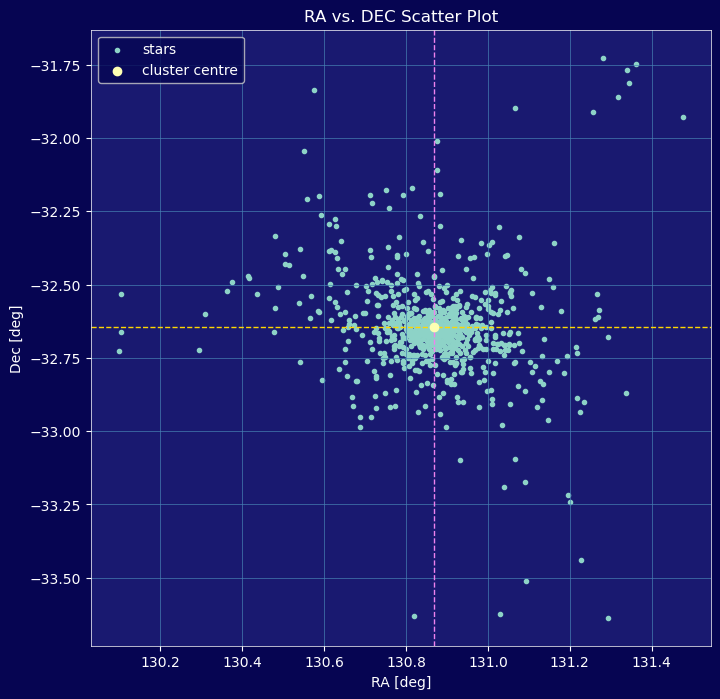

In [7]:
plot_deg = plot_my_cluster((8,8), 'deg')

In [8]:
print(f'total number of stars: {len(my_cluster)}')

total number of stars: 845


#### 1.b.ii *Comment on any structure you see in the scatter plot and how this might affect a radially binned profile.*

It seems that the cluster is generally pretty uniformly distributed in structure. However: 
- RA: I do see a slightly larger variance in Right Ascension on the left side of the cluster (evident with stars at the lower edge (< 130.2 deg), and also in the right-ward skew of the RA center coordinate (pink dashed line)). 

- DEC: 
        
    * i. to the left of center, there is slight asymmetry below and above the declination centre line (slightly more uniformly distributed along a 45 degree line from center towards upper left quadrant than the lower left quadrant, more densely clustered in center)

    * ii. to the right of center, there is a higher variance in declination than on the left side 

- overall, the cluster's structure tends to lie more prominently in the three regions encapsulated by ($\text{RA} \gt \text{RA}_{center}$ and $\text{DEC} \gt \text{DEC}_{center}$) 

- this might affect a radially binned profile by skewing distributions into this region and only being representative along certain slices 

- however now I realize if it is radial, then these three arm-looking structures, if the general distribution amongst them is isotropic, then radial binning should be fine. 

### 1.c. 
*We will now bin the stellar radii into a radial density profile by gathering all stars in annuli (donut-shaped area between two bounds $R_j$ and $R_{j+1}$). First, predict: How will the number of low-count bins change when going from $J = 15$ to $J = 50$ bins? Give a specific numeric expectation (e.g. “I expect the number of bins with counts $𝑁 < 5$ to increase by $X$ amount”) and justify your prediction using the scatter plot you’ve made.*

Answer: 

Here's what I know so far: there are 845 stars in my sample, and the scatter plot seems to show a spatial distribution that seems to increase exponentially in density towards the center coordinates (like if I were to draw a 45 degree line from the center outwards to the corners of my plots). 

With 15 bins, I anticipate the majority of the stars to be inside of the first (innermost radial) bin (~ 500), with the next 200 or so in the second innermost bin, and the final ~150 distributed within bins 3-6 and <30 in the bins 7-15, with the outermost bins having $N \lt 10$. 

From 15 to 50 bins, I anticipate that the number of bins with counts N < 5 to increase by a factor ~ 3.3 (50/15). I am looking at the scatter plot again, and when I don't divide by the center lines, I see that the cluster itself looks like it might have three arms, or at least three locations of outer density: 
1. Right of RA center \& above DEC center, 
2. Right of RA center \& below DEC center, 
3. left of RA center along DEC center line. 

These three dense spots actually seem pretty uniformly distributed (not exponential like the inner parts) so I would assume a linear (so just by factor 50/15) change in the low-count bins rather than a logarithmic one. 

### 1.d.

Set the maximum radius $R_{max}$ to the largest angular projected radius, and define bin edges 0 = $R_0 \lt R_1 \lt \cdots \lt R_J = R_{max}$. Make radial profiles for both $J = 15$ and $J = 50$. For each profile compute: 

* star counts $N_j$ for each annulus $j$ 

* the annulus area $A_j = \pi(R_{j + 1}^2 - R_j^2)(\text{arcmin}^2)$

* mid-radius $R_{j, mid} = \frac{(R_{j + 1}^2  + R_j^2)}{2}$

* empirical surface density: $\hat \Sigma_j = \frac{N_j}{A_j}$

* how many bins satisfy $N_j \lt 1$, $N_j \lt 5$, and $N_j \lt 10$



Just to keep track of the math: 
* defining the bins as instructed means that each bin j has stars with $R_j \leq R \leq R_{j + 1}$
* so, the edges array will have length $J + 1$

In [9]:
# set R_max 
Rmax = max(my_cluster['proj_radii'])
# set bin numbers
J_15 = 15
J_50 = 50
# define bin edges as arrays
bin_array_15 = np.linspace(0, Rmax, J_15 + 1)
bin_array_50 = np.linspace(0, Rmax, J_50 + 1)

I know I am kind of re-inventing the wheel in this next cell (as in there are much easier ways of doing this), but for some reason I decided to do it all out like this. 

In [11]:
def count_stars_annulus(bin_edges_array, cluster, print_counts = True): 

    ''' 
    Function takes inputs of the intended bin edges, the cluster from 
    the Gaia data set, and a command to print the counts, and outputs 
    a dataframe containing counts, areas, mid-radii and surface densities
    for each bin. 
    '''

    num_bins = len(bin_edges_array) - 1
    # setting up bin outputs for future list making
    bin_counts = np.zeros(num_bins, dtype=int)
    annulus_areas = np.zeros(num_bins, dtype = float)
    mid_radii = np.zeros(num_bins, dtype = float)
    surface_densities = np.zeros(num_bins, dtype = float)
    stars_binned = []

    # pulling out only relevant pieces of dataframe for this loop 
    names_proj_radii = cluster[['Name', 'proj_radii']] # dataframe of interest

    for j in range(num_bins): 
        # define annulus 
        inner_annulus_boundary = bin_edges_array[j]
        outer_annulus_boundary = bin_edges_array[j+1]
        annulus_area = np.pi*(outer_annulus_boundary**2 - inner_annulus_boundary**2)
        annulus_areas[j] = annulus_area
        mid_radii[j] = (outer_annulus_boundary + inner_annulus_boundary)/2
        # now doing counting 
        stars_in_bin = (names_proj_radii['proj_radii'] >= inner_annulus_boundary) & (names_proj_radii['proj_radii'] < outer_annulus_boundary)
        bin_counts[j] = np.sum(stars_in_bin)
        binned_stars_with_names = names_proj_radii.loc[stars_in_bin]
        stars_binned.append(binned_stars_with_names)
        # calculate surface density 
        surface_densities[j] = bin_counts[j]/annulus_area

    question_1d_dict = {'bin counts': bin_counts, 
                        'annulus areas': annulus_areas, 
                        'mid-radii': mid_radii, 
                        'surface density': surface_densities, 
                        'stars in bins': stars_binned}
    
    binning_dataframe_nonames = pd.DataFrame(question_1d_dict).drop(columns = 'stars in bins') 

    N_less_than_1 = np.sum(bin_counts < 1)
    N_less_than_5 = np.sum(bin_counts < 5)
    N_less_than_10 = np.sum(bin_counts < 10)

    low_counts = [N_less_than_1, 
                  N_less_than_5, 
                  N_less_than_10]
    
    if print_counts == True:
        print(f'N < 1: {low_counts[0]}')
        print(f'N < 5: {low_counts[1]}')
        print(f'N < 10: {low_counts[2]}')

    return binning_dataframe_nonames, low_counts, question_1d_dict


In [12]:
binning_15, _, __ = count_stars_annulus(bin_array_15, my_cluster, print_counts=True)
print('15-bin results: ')
binning_15

N < 1: 0
N < 5: 6
N < 10: 8
15-bin results: 


,bin counts,annulus areas,mid-radii,surface density
0,343,55.6926,2.1052,6.1588
1,210,167.0778,6.3156,1.2569
2,122,278.4630,10.5260,0.4381
3,57,389.8481,14.7364,0.1462
4,48,501.2333,18.9468,0.0958
5,22,612.6185,23.1572,0.0359
6,17,724.0037,27.3676,0.0235
7,4,835.3889,31.5780,0.0048
8,1,946.7741,35.7884,0.0011
9,7,1058.1592,39.9988,0.0066


In [13]:
binning_50, _, __ = count_stars_annulus(bin_array_50, my_cluster, print_counts=True)
print('50-bin results (trunc):')
binning_50.head(15)

N < 1: 12
N < 5: 28
N < 10: 34
50-bin results (trunc):


,bin counts,annulus areas,mid-radii,surface density
0,62,5.0123,0.6316,12.3695
1,126,15.0370,1.8947,8.3793
2,124,25.0617,3.1578,4.9478
3,86,35.0863,4.4209,2.4511
4,73,45.1110,5.6840,1.6182
5,48,55.1357,6.9472,0.8706
6,49,65.1603,8.2103,0.7520
7,45,75.1850,9.4734,0.5985
8,32,85.2097,10.7365,0.3755
9,30,95.2343,11.9997,0.3150


### 1e: *Make the following plots:*
* *$\hat \Sigma_j$ vs $R_{j,mid}$ with approximate uncertainty $\sqrt{\frac{N_j}{A_j}}$*

* *$N_j$ vs $R_{j,mid}$ with approximate uncertainty $\sqrt{N}$*

Note: these are good approximate uncertainties because this data is Poisson-distributed. 


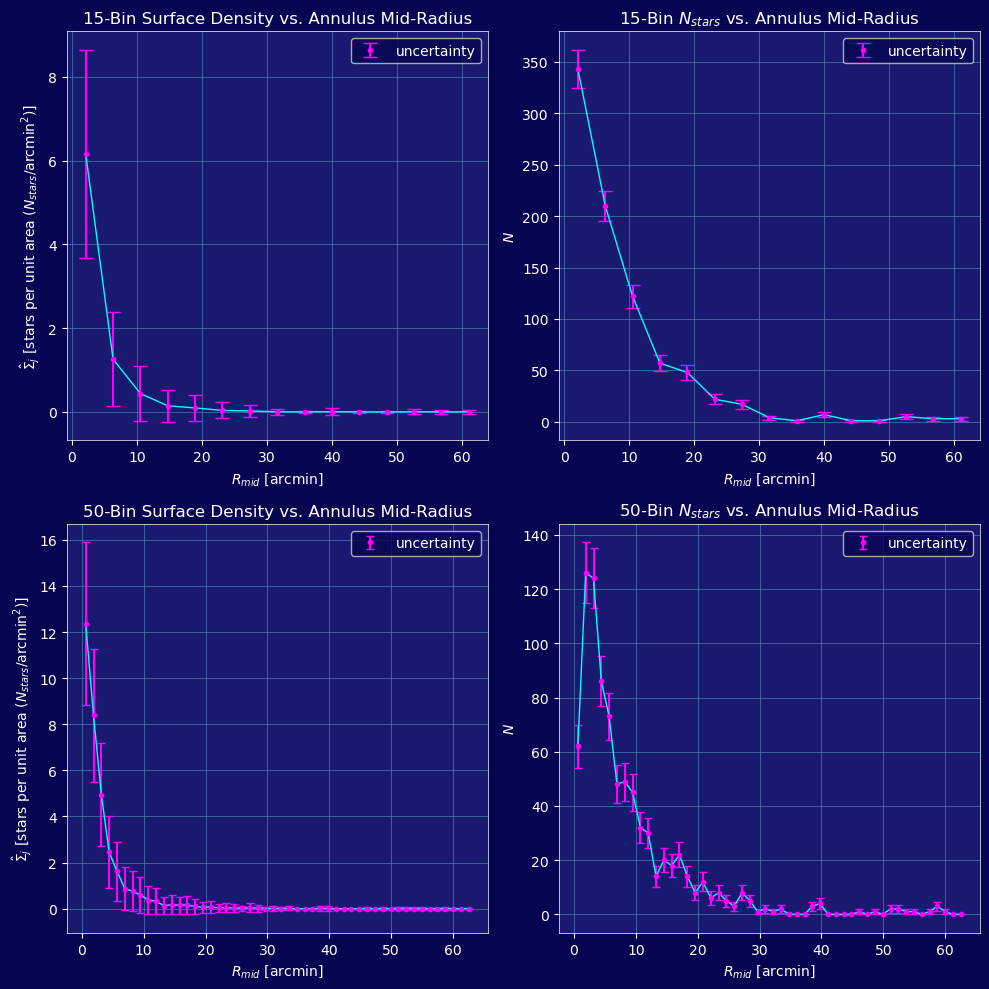

In [14]:
fig, ax = plt.subplots(2, 2, figsize = (10,10))

ax[0,0].errorbar(binning_15['mid-radii'], binning_15['surface density'], 
               yerr=np.sqrt(binning_15['bin counts']/binning_15['annulus areas']), 
               fmt='.', color = 'magenta', capsize = 5, label = 'uncertainty')
ax[0,0].plot(binning_15['mid-radii'], binning_15['surface density'], color = 'cyan', lw = 1)
ax[0,0].set_xlabel('$R_{mid}$ [arcmin]')
ax[0,0].set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax[0,0].set_title('15-Bin Surface Density vs. Annulus Mid-Radius')
ax[0,0].legend()

ax[0,1].errorbar(binning_15['mid-radii'], binning_15['bin counts'], 
               yerr=np.sqrt(binning_15['bin counts']), 
               fmt='.', color = 'magenta', capsize = 5, label = 'uncertainty')
ax[0,1].plot(binning_15['mid-radii'], binning_15['bin counts'], color = 'cyan', lw = 1)
ax[0,1].set_xlabel('$R_{mid}$ [arcmin]')
ax[0,1].set_ylabel('$N$')
ax[0,1].set_title('15-Bin $N_{stars}$ vs. Annulus Mid-Radius')
ax[0,1].legend()

ax[1,0].errorbar(binning_50['mid-radii'], binning_50['surface density'], 
               yerr=np.sqrt(binning_50['bin counts']/binning_50['annulus areas']), 
               fmt='.', color = 'magenta', capsize = 3, label = 'uncertainty')
ax[1,0].plot(binning_50['mid-radii'], binning_50['surface density'], color = 'cyan', lw = 1)
ax[1,0].set_xlabel('$R_{mid}$ [arcmin]')
ax[1,0].set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax[1,0].set_title('50-Bin Surface Density vs. Annulus Mid-Radius')
ax[1,0].legend()


ax[1,1].errorbar(binning_50['mid-radii'], binning_50['bin counts'], 
               yerr=np.sqrt(binning_50['bin counts']), 
               fmt='.', color = 'magenta', capsize = 3, label = 'uncertainty')
ax[1,1].plot(binning_50['mid-radii'], binning_50['bin counts'], color = 'cyan', lw = 1)
ax[1,1].set_xlabel('$R_{mid}$ [arcmin]')
ax[1,1].set_ylabel('$N$')
ax[1,1].set_title('50-Bin $N_{stars}$ vs. Annulus Mid-Radius')
ax[1,1].legend()
plt.tight_layout()



### 1f: Binning

Because the count seems to consistently go to zero around 25 annuli (the uncertainty in both the surface density and count plots decreases much more prominently for the 50-bin version ), and to make some room for some remaining smaller structures, I am choosing to use 30 bins. Above that, I believe I will run into *too* fine structures for this analysis (like how there are only 60 stars in the first bin of the 50-bin slice, right before it shoots up to around 125 stars). But perhaps these intricacies are important, and I will lose those with these new bins. I am trading away redunancy that allows for smaller-scale structures in favor of a more streamlined description with potentially missing smaller scale information. Perhaps also those three arms are unequal on smaller scales which could give rise to something interesting in the bins, and that too I might not see given that those bins are in the outer radial range. 

In later sections I return to this choice and reevaluate. *(In retrospect: I was more worried about smaller structures at large radii when I should have been concerned with the small radii.)* 

Here, I am creating a function to get my final set of bins to use for the following analysis. 

In [15]:
# based on my other work above, just in case I need to 
# try with different bin size later
def set_bins_get_data(cluster, n_bins):
    """ 
    given inputs for specific cluster already modified with added projected radii and 
    preferred number of bins, outputs numpy arrays for the mid-radii, areas, and star 
    counts per annulus bin

    Inputs: cluster, n_bins
    Outputs: R_mid, Areas, Ns
    
    """
    Rmax = max(cluster['proj_radii']) # pull out Rmax, dependent on my own column naming
    bin_array = np.linspace(0, Rmax, n_bins + 1)
    bins_df, _, _ = count_stars_annulus(bin_array, cluster, print_counts=False)
    Ns = bins_df['bin counts']
    Areas = bins_df['annulus areas']
    R_mid = bins_df['mid-radii']
    return R_mid, Areas, Ns, bins_df

## Exercise 2: Likelihood & Prior

### 2.a. Likelihood choice
*You must decide which likelihood is appropriate for the binned radial dataset you constructed. Typical choices for a likelihood include:*

* *Poisson likelihood for count data*
* *Gaussian likelihood*
* *Another reasonable approximation.*

*In ~3–5 sentences, explicitly connect your choice of likelihood to the number of zero/low-count bins and where they occur in radius. State one specific failure mode you would expect if you used the other likelihood, referencing your computed results.*


I am choosing the Poisson likelihood, with $N_j \sim \text{Poisson}(\Sigma(R_{j,mid})A_j)$. I think that this is a reasonable choice because (a) this experiment is in *counting* which is the underlying mechanism of a Poisson distribution (each annulus has a star count). This likelihood is particularly good or the zero and low-count bins, because Poisson handles zero counts well due to its logarithmic structure; this is in contrast to choosing a Gaussian, which might work okay for inner radii, however for the zero count bins, this should break down. A Gaussian distribution assumes either symmetric errors independent of the count, or a variance determined by count (usually $\sigma = \sqrt{N_j}$). This will lead to failure for low or zero-count bins because this would imply the noise is equal or close to 0 even though that may not be the case for the surrounding bins, which would cause a discontinuity in noise. Additionally, for low counts, the Gaussian's symmetry leads to negative values being given weight even when uncertainty is one sided (like needing to be > 0). 

### 2.b. King model 

*We will now connect the model introduced in the beginning of the assignment, the King radial profile model, to our data, using the likelihood you chose. Write a function that computes your likelihood: you’ll want that function that takes in a vector of parameters and the data and computes the logarithm of the likelihood you’ve chosen for a given model. For a set of parameters you guess should be reasonable based on the profile you’ve plotted in Exercise 1, show that the log-likelihood returns a finite value.*

Reminder of the King model: 
$$
\Sigma_{\text{cl}}(R) = \Sigma_0\left(\frac{1}{\sqrt{1 + (R/r_c)^2}} - \frac{1}{\sqrt{1 + (r_t/r_c)^2}}\right)^2, 
$$
where
$$
0 \leq R \leq r_{t}
$$
with 
* $ \Sigma_0 \gt 0 $ as the central surface density 
* $ r_c \gt 0 $ the core radius: defined as distance at which apparent surface luminosity drops by half (on order ~ few pc) 
* $ r_t \gt r_c $ the tidal radius: the distance from center of cluster at which external gravitation of host galaxy has more influence over stars in cluster than does the cluster itself, i.e. distance where individual stars belonging to cluster can actually be unbound by the galaxy (usually much larger than core radius, on order 100 pc). I infer this to mean this is the crucial point where $g_{cluster} \approx g_{gal, tidal}$, i.e. $\text{cluster gravity} \approx \text{tidal force of galaxy}$





In this first step, what I understand is that we are trying to fit the King profile function to the data. As I have chosen to use Poisson, I will have to approximate the counts per bin as 
$$
\lambda_j \approx \Sigma(R_{j,mid})A_j
$$. 

Also since the log-likelihood of Poisson will be -inf if $\Sigma = 0$, I will implement the hack of adding a very small (1e-10) background to the King profile, such that it will actually be
$$
\lambda_j \approx (\Sigma(R_{j,mid}) + \Sigma_{bg})A_j
$$

Here, first I need to define a likelihood function. For count data $\lambda_j$, and distribution $N_j \sim \text{Poisson}(\lambda_j)$, per the notes and online site, this is represented by: 

$$
p(N_j|\lambda_j) = \frac{\lambda_j^{N_j}e^{-\lambda_j}}{N_j!}
$$

and given multiple independent parameters described by $\theta$, full likelihood can be written: 

$$
\text{likelihood}(\theta) = p(N_j|\theta) = \prod_{j=1}^J p(N_j|\lambda_j(\theta))
$$
with logs, where products become sums, and is what the log-likelihood function will compute: 
$$
L(\theta) = \log p(N_j|\theta) = \sum_{j=1}^J[N_j \log \lambda_j - \lambda_j - \log(N_j!)]
$$


In [16]:
# so just setting up likelihood

# from given script: 


def sigma_king_cluster(R, Sigma0, R_c, R_t):
    """
    A King profile for the surface density of the cluster.

    Parameters
    ----------
    R : numpy.ndarray
        A array of radius values for which to compute the surface profile

    Sigma0 : float
        The central surface density

    r_c, r_t, float, float
        The core radius and tidal radius

    Returns
    -------
    Sigma : numpy.ndarray
        An array with the surface density at the radii R
    """
    term_t = 1.0 / np.sqrt(1.0 + (R_t/R_c)**2)
    term_R = 1.0 / np.sqrt(1.0 + (R/R_c)**2)
    Sigma = Sigma0 * (term_R - term_t)**2
    Sigma = np.where(R <= R_t, Sigma, 0.0)
    return Sigma

# Poisson likelihood

def convert_Sigma_poisson_loglikely(theta, R_mid, Areas, Ns):
    """ 
    Function to compute likelihood given vector of parameters and Radius, using the King profile, 
    which first converts the surface density profile by adding a very small background and then approximates
    into counts (lambda) per the Poisson distribution
    
    Parameters
    ----------
    Theta : numpy.ndarray
        to be inputted during fitting, array including central surface density, core radius and tidal radius
    R_mid : numpy.ndarray 
        mid-radii computed in the previous section for the radius corresponding to the middle of each annulus
    Areas : numpy.ndarray
        Array of areas from the work done above
    Ns: bin counts 

    Returns
    -------
    Poisson likelihood given parameters
    """

    # set parameters
    Sigma_0, R_c, R_t = theta # these will be guesses in actual testing

    # first compute sigma and convert to lambda
    Sigma_King = sigma_king_cluster(R_mid, Sigma_0, R_c, R_t) # king model 
    Sigma_BG = 1e-10 # background to avoid -inf
    Sigma = Sigma_King + Sigma_BG # combine to radial profile
    Lambda = Sigma*Areas # multiply by areas for approx counts

    # return likelihood for Poisson
    log_likely = np.sum(Ns*np.log(Lambda) - Lambda - gammaln(Ns + 1))

    return log_likely


# get the newly binned data (30 bins)
R_mid_30, Areas_30, Counts_30, df_30 = set_bins_get_data(my_cluster, 30)


In [17]:
# just a test to make sure there are no asymptotes

guess_Sig0 = np.max(Counts_30/Areas_30) # assume center surface density is maximum of counts per area
theta_guess = (guess_Sig0, 0.2, 5.0) # 0.2 and 5 arcminutes
value = convert_Sigma_poisson_loglikely(theta_guess, R_mid_30, Areas_30, Counts_30)
print(value, np.isfinite(value))


-12107.873014040242 True


### 2.c.
*You will perform posterior inference using Markov Chain Monte Carlo. Implement the following priors for the three parameters in the model:*
* *$r_c \sim \text{Uniform}(0, 1)$ [arcmin]*
* *$r_t \sim \text{Uniform}(r_c, 10)$ [arcmin]*
* *$\Sigma_0 \sim \text{Half Normal}(\sigma_0)$ with some appropriate scale $\sigma_0$*

In [18]:
# both from assignment2.py

def log_halfnormal(x, s):
    """
    Computes the log-pdf of a half-normal 
    probability distribution, i.e. a distribution 
    that's 0 below 0 and Gaussian above.

    Parameters
    ----------
    x : np.ndarray or float
        An array or scalar with the value(s) for which to 
        compute the prior pdf

    s : float
        The scale parameter of the distribution

    Returns
    -------
    pdf : float or np.ndarray
        the log-pdf for the values in x
    """
    if x < 0:
        return -np.inf
    # HalfNormal density: sqrt(2/pi)/s * exp(-x^2/(2s^2))
    return float(np.log(np.sqrt(2/np.pi)) - np.log(s) - 0.5*(x/s)**2)

def log_uniform(x, a, b):
    """
    Computes the log-pdf for a uniform distribution
    between bounds a and b, outside of which the 
    pdf will be zero (or the log-pdf -inf)

    Parameters
    ----------
    x : np.ndarray or float
        An array or scalar with the value(s) for which to 
        compute the prior pdf

    a, b : float, float
        The lower and upper boundary for the distribution

    Returns
    -------
    pdf : float or np.ndarray
        the log-pdf for the values in x    
    """
    if (x < a) or (x > b):
        return -np.inf
    return float(np.log(b - a))

#### 2.c.i. *Choose an appropriate scale for $\Sigma_0$ and justify your choice using prior results and figures.*

From my understanding, the scale parameter of a log normal distribution corresponds roughly to the standard deviation of the log normal (or log half-normal) distribution. However in this case it cannot be inferred from the data, and instead, the scale parameter should set the plausible magnitude for the central surface density before the fitting happens. Therefore, I choose the scale parameter $\sigma$ to be the same order of magntiude of the crudely calculable central surface density ($\text{max}(N_j/A_j)$), which will make this prior weakly informative as it only enforces a zero probability to all $\Sigma_0 < 0$, and nonzero probability to all $\Sigma_0>0$ which here is required of the chosen half-normal prior. Based on the calculation below, I am setting the scale parameter to be 10. I wanted to look into this because I didn't really understand what the prior and its scale parameter were actually doing. From the ```assignment2.py``` I found that for this application with $\Sigma_0$, the half-normal density is 
$$
P(\Sigma_0) = \sqrt{\frac{2}{\pi}} \exp\left(-\frac{\Sigma_0^2}{2s^s}\right)
$$

Here is what I can infer that this log half-normal does, which is a few things: 
- $\Sigma_0 << s$: almost no penalty
- $\Sigma_0 \sim s$: mild penalty
- $\Sigma_0 >> s$: increasingly penalized but never forbidden.

So basically, choosing $\sigma$ to be around the same as the calculated central density doesn't bias the posterior in favor of it, rather it just makes sure the sampler doesn't go into super large density unless the likelihood causes that to happen. 

In [19]:
sigma_30 = Counts_30/Areas_30
# looking for central surface density as just max, not removing background, need order of magnitude
sigma_30_scale = np.max(sigma_30) 
sigma_30_scale

10.557957300405828

So for the scale paramter, I will be using $\sigma = 10$.

#### 2.c.ii. *Choose some possible parameter values for each parameter: two values you think are reasonable in the context of your cluster, and two that are way off, and compute the prior log-probability density for them. Is the output of the prior sensible?*

Projected Radii stats: 
 count   845.0000
mean      8.5826
std       9.3033
min       0.1302
25%       2.8289
50%       5.5454
75%      10.8897
max      63.1561
Name: proj_radii, dtype: float64
Binned Sigma stats: 
 count   30.0000
mean     0.6495
std      2.0797
min      0.0000
25%      0.0018
50%      0.0093
75%      0.1405
max     10.5580
Name: surface density, dtype: float64


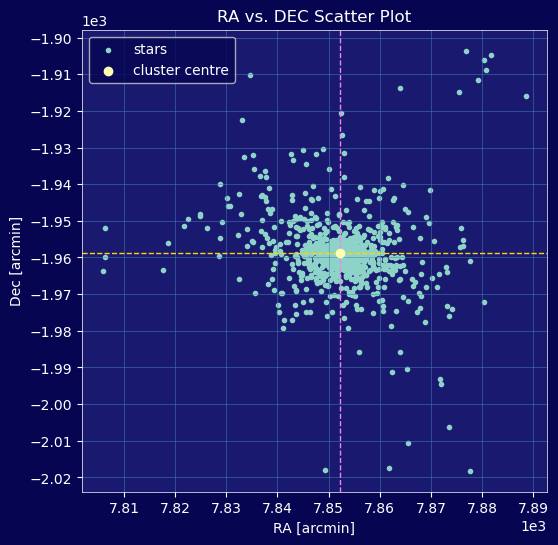

In [20]:
print(f'Projected Radii stats: \n {my_cluster["proj_radii"].describe()}')
print(f'Binned Sigma stats: \n {df_30["surface density"].describe()}')
cluster = plot_my_cluster((6,6), 'arcmin')

Based on the plot of empirical surface density vs. projected radius, as well as the statistics about my sample that I printed above, I think that a good scale of the log-Half-Normal to use would be $\sigma_0 = 10$, as that is at least the correct order of magnitude for what I think the $\Sigma_0$ should be. I was confused with this prior parameter, until I now understand that it encodes kind of my prediction for what the value should be. 

Looking at my cluster's empirical surface density and radial projection statistics as well as the plots of surface density vs. radius from Exercise 1 and the cluster scatter plot itself, some reasonable and unreasonable guesses: 

* $\Sigma_0$
    * Reasonable: (10.55, 9), Unreasonable: (-1, -70)
* $r_c$
    * Reasonable: (0.4, 0.5), Unreasonable: (-1, -5) 
* $r_t$
    * Reasonable: (5, 6), Unreasonable: (0.1, 11) 

Computing log probability densities for them: 

In [22]:
def Rc_prior(Rc_guess): 
    Rc_log_uniform = log_uniform(Rc_guess, 0, 1) # between 0 and 1 arcminutes
    return Rc_log_uniform

def Rt_prior(Rt_guess, Rc_guess): 
    Rt_log_uniform = log_uniform(Rt_guess, Rc_guess, 10) # between given Rc and 10 arcminutes
    return Rt_log_uniform

def sigma_prior(Sigma0_guess, sigma_scale):
    Sigma0_halfnorm = log_halfnormal(Sigma0_guess, sigma_scale)
    return Sigma0_halfnorm

In [23]:
# computing for all possibilities, where guesses are set up like 
# [[reasonable 1, reasonable 2], [unreasonable 1, unreasonable 2]]

def compute_priors_guesses(var, guesses, sigma_scale = None, Rc_Rt_guess = None):

    """ computes and reports log probability density for guesses as assigned in 2.c.ii"""

    if var == 'sigma': 
        reas_1 = sigma_prior(guesses[0][0], sigma_scale)
        reas_2 = sigma_prior(guesses[0][1], sigma_scale)
        unreas_1 = sigma_prior(guesses[1][0], sigma_scale)
        unreas_2 = sigma_prior(guesses[1][1], sigma_scale)

    elif var == 'R_c': 
        reas_1 = Rc_prior(guesses[0][0])
        reas_2 = Rc_prior(guesses[0][1])
        unreas_1 = Rc_prior(guesses[1][0])
        unreas_2 = Rc_prior(guesses[1][1])

    elif var == 'R_t':
        reas_1 = Rt_prior(guesses[0][0], Rc_Rt_guess)
        reas_2 = Rt_prior(guesses[0][1], Rc_Rt_guess)
        unreas_1 = Rt_prior(guesses[1][0], Rc_Rt_guess)
        unreas_2 = Rt_prior(guesses[1][1], Rc_Rt_guess)

    print(f'Log Probability Densities for {var} Guesses')
    print(f'Reasonable Guesses: \n {guesses[0][0]}: {reas_1} \n {guesses[0][1]}: {reas_2}')
    print(f'Unreasonable Guesses: \n {guesses[1][0]}: {unreas_1} \n {guesses[1][1]}: {unreas_2}')


# saving guesses here
sigma_guesses = [[10.5, 8], [-1, -70]] 
Rc_guesses = [[0.4, 0.5], [-1, -5]]
Rt_guesses = [[5, 9], [0.1, 11]]

# compute priors for these guesses
compute_priors_guesses('sigma', sigma_guesses, sigma_scale = 10)
print(' ')
compute_priors_guesses('R_c', Rc_guesses)
print(' ')
compute_priors_guesses('R_t', Rt_guesses, Rc_Rt_guess = 0.5)


Log Probability Densities for sigma Guesses
Reasonable Guesses: 
 10.5: -3.079626445638773 
 8: -2.848376445638773
Unreasonable Guesses: 
 -1: -inf 
 -70: -inf
 
Log Probability Densities for R_c Guesses
Reasonable Guesses: 
 0.4: 0.0 
 0.5: 0.0
Unreasonable Guesses: 
 -1: -inf 
 -5: -inf
 
Log Probability Densities for R_t Guesses
Reasonable Guesses: 
 5: 2.2512917986064953 
 9: 2.2512917986064953
Unreasonable Guesses: 
 0.1: -inf 
 11: -inf


The outputs of the priors here are sensible. The unreasonable guesses are all -inf, meaning probability density = 0. The reasonable guesses output either negative numbers (low but nonzero probability density) for the $\Sigma_0$ guesses, 0 for the $R_c$ guesses: maximum relative probability, which means these values have an equal log probability (log uniform is constant within allowed bounds!), and positive identical values for the conditional prior of the tidal radius $R_t$. Seems like the code is working fine. 

#### 2.c.iii. *Write a function that computes the logarithm of the joint prior probability density given an input vector of parameters.*

In [24]:
# as if they are independent? 

def joint_prior_prob(theta, sigma_scale): 
    '''
    Function computes the joint prior probability of the parameters of central surface density, core radius and tidal radius 
    based on inputs of parameter guesses and the pre-decided scale for Sigma. 

    Parameters 
    ----------
    theta :  np.ndarray -- an array of values in order 1) central surface density, 2) 
             core radius, 3) tidal radius

    sigma_scale : float -- this is a necessary input for the half-normal distribution, 
                  for which I am typically going to use a value of 10 given 
                  an explanation above. 
                 
    Returns
    -------
    prior: float -- value of the joint probability for a given set of input parameters

    '''

    Sigma0, R_c, R_t = theta
    log_joint_prob = sigma_prior(Sigma0, sigma_scale) + Rc_prior(R_c) + Rt_prior(R_t, R_c) # just the sum because log!
    return log_joint_prob

So this is not assuming independence, because in reality, I have coded the joint probability of the tidal and core radius into the joint prior because the tidal radius is dependent on the core radius in its construction: 

$$
\log P(r_c, r_t, \Sigma_0) = \log P(r_c) + \log P(r_t|r_c) + \log P(\Sigma_0)
$$

where we have constructed log-uniform (scale invariant) priors on core radius and tidal radius, and a half-normal prior for the central surface density. 

## Exercise 3: Posterior Inference

### 3.a. *Write a function that computes the log-posterior, using the two functions for the log-likelihood and the log-prior.*

Before writing this function, I just want to remind myself of good old Bayes. Here, I am working to emulate
$$
\text{posterior} \propto \text{likelihood} \times \text{prior}
$$

where the output shall define the posterior probability of a vector of parameters given my data, which in this case, will be the count data ($N_i$), proportional to the Poisson likelihood I have defined (counting) times the prior I just set up (flat prior?)
$$
p(\theta|N_i) \propto p(N_i|\theta) \times p(\theta)
$$

and when put into log form this will give the log-posterior: 
$$
\log p(\theta|N_i) = \log p(N_i|\theta) + \log p(\theta)
$$

and when put into a big mess, actually represents this: 
$$
\log p(\theta|N_i) = \left[\sum_{j=1}^J[N_j \log \lambda_j - \lambda_j - \log(N_j!)]\right] + \Biggl[ \log P(r_c) + \log P(r_t|r_c) + \log P(\Sigma_0) \Biggr]
$$

In [25]:
# now writing log-posterior function 
def log_post(theta): 

    '''
    Function will take the input of values for joint_prior_prob and 
    convert_sigma_poisson_loglikely, hard-coding certain parameters
    and compute the log posterior based on these two computations
    
    Parameters
    ----------
    
    theta : numpy.ndarray
        to be inputted during fitting, array including (in order) 
        central surface density, core radius and tidal radius             

    Returns
    -------
    log_posterior : the log posterior for the given input parameters 
    
    '''
    
    # here, hard-coding the parameters which I do not plan to change for 
    # the rest of the notebook
    sigma_scale = 10
    #sigma_scale = 5
    #sigma_scale = 30
    R_mid = R_mid_30
    Areas = Areas_30
    Ns = Counts_30

    # define factors 
    log_joint_prior = joint_prior_prob(theta, sigma_scale)
    if not np.isfinite(log_joint_prior):
        return -np.inf # debugging purposes 
    log_likelihood = convert_Sigma_poisson_loglikely(theta, R_mid, Areas, Ns)
    
    # compute posterior 
    log_posterior = log_likelihood + log_joint_prior

    return log_posterior

### 3.b. 
*Choose an MCMC algorithm (a standard choice in astronomy/physics is the affine-invariant ensemble sampler implemented in the emcee library). Note: you are not required to write your own MCMC sampler! You are free to use any MCMC sampling library you would like. Make an initial choice for the total number of steps and the number to be discarded as burn-in steps, and record those numbers. Also record the number of chains/walkers, and any hyperparameters (i.e. parameters of the sampling process) you may have set (note: not all algorithms require you to manually set parameters).*

Okay, here I will first import the emcee library and then set some initial parameters, as per the suggested affine-invariant ensemble sampler. For walkers, I'm doing 20, and using 5000 steps per chain and having a 10% burn-in with 500, for no real reason at all but needing to put numbers down. 

In [42]:
import emcee 
# parameter setting 
n_dimensions = 3 # for the three theta values
n_walkers_init = 20 # number of chains
n_steps_init = 5000 # steps per chain 
n_burned_init = 500 # burn in steps 
total_steps = n_steps_init * n_walkers_init
print('Initial Parameters for MCMC: \n----------------------------')
print(f'Walkers: {n_walkers_init}')
print(f'Steps per chain: {n_steps_init}')
print(f'Burned steps per chain: {n_burned_init}')
print(f'Total Steps: {total_steps}')


Initial Parameters for MCMC: 
----------------------------
Walkers: 20
Steps per chain: 5000
Burned steps per chain: 500
Total Steps: 100000


### 3.c. Starting positions 
*Compute starting positions: To get MCMC to run well, you’ll need to choose reasonable starting positions. Often, you use a maximum likelihood fit, or you can calculate these from the data (e.g. the mean of the last few bins makes a good starting position for the background rate). Here, choose reasonable starting positions based on summaries you can compute from your cluster profile or from what you can eyeball from your observed profile. Justify how you’ve chosen the starting positions.Then slightly randomize the starting positions for each chain by drawing from a small Gaussian (variance ~10^-2) around those starting positions.* 

*Hint: make sure that after drawing from the Gaussian, your starting points are all within the prior bounds by checking that the logprior of those starting positions is a well-defined number! You might want to generate more starting positions than you need and then simply choose a subset that is guaranteed to be within the prior bounds*

First, for picking starting positions: 
- $\Sigma_0$: I will use the background estimate based on the hint from the PDF, where 
$$ \Sigma_{0,\text{ guess}} = \text{max}(\Sigma_{\text{peak}} - \text{mean} (\Sigma_{\text{outer bins}}))$$

In [27]:
# choosing starting position

sigma_30 = Counts_30 / Areas_30
sigma_30_bg = np.mean(sigma_30[-5:])
sigma_0_guess = np.max(sigma_30 - sigma_30_bg)
print(sigma_0_guess)

10.555844576642695


The core radius in the King profile is defined where the cluster surface density drops by half. In my plots from part 1, this looks like it happens somewhere around 2 or 3 arcminutes. However the prior requires that the guess for the core radius be less than 1, so I will push it as high as possible into that limit for my guess (~0.99999999 arcmin). 

Then, the tidal radius needs to be less than 10 (and greater than $R_c$) per the prior, however looking at my scatter plot, a crude estimate would place this tidal radius at least at 10 arcminutes if not more. So this too, I will guess at a high limit below the boundary of 10 arcmin. 

In [28]:
# same number of 9s after decimals as the sigma_0_guess, for nothing but consistency (don't think big effect mathematically)
first_pos_guesses = np.array([sigma_0_guess, 0.999999999999999, 9.999999999999999]) 

Now randomizing, with a variance of $10^{-2}$: 

In [29]:
rng = np.random.default_rng(33)

def get_randomized_inf_check(starting_theta, n_walkers, n_dims):
    '''Just making this in case I need to re-generate the random sample with different emcee params
    COME BACK AND ANNOTATE THIS FUNCTION
    '''
    # randomize position
    position = starting_theta + 0.1*rng.standard_normal(size=(n_walkers, n_dims)) # variance of 10^-2

    # this is a little while bit that makes sure things are within the bounds of the prior
    # and resamples if it has an infinite output 
    out_of_bounds = ~np.isfinite([joint_prior_prob(pos, 10) for pos in position])
    while np.any(out_of_bounds): # this just makes sure 
        position[out_of_bounds] = starting_theta + 0.1 * rng.standard_normal(size = (out_of_bounds.sum(), n_dims))
        out_of_bounds = ~np.isfinite([joint_prior_prob(pos, 10) for pos in position])
    
    return position

# use randomizer
pos1 = get_randomized_inf_check(first_pos_guesses, n_walkers_init, n_dimensions)

Now running the actual sampler, and doing it for 20 chains. 

In [30]:
# this block I am using with the help of my friend and classmate, Ana Mare

sampler = emcee.EnsembleSampler(n_walkers_init, n_dimensions, log_post)
print("Sampler Running")
sampler.run_mcmc(pos1, n_steps_init, progress = True)
samples = sampler.get_chain(discard = 0, flat = False)

# first run: 00:01:02

Sampler Running


100%|██████████| 5000/5000 [00:31<00:00, 156.92it/s]


In [31]:
len(samples)

5000

## Exercise 4: Diagnostics 

### 4.a. Trace Plots 

*Show trace plots for all parameters of the entire chain (with burn-in). Clearly mark the part of the chain to be discarded as burn-in.*

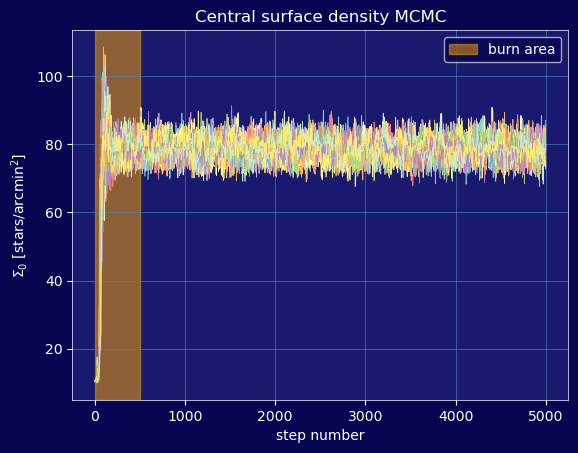

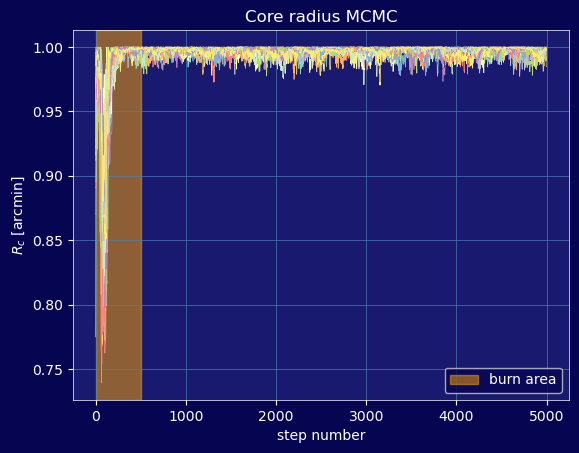

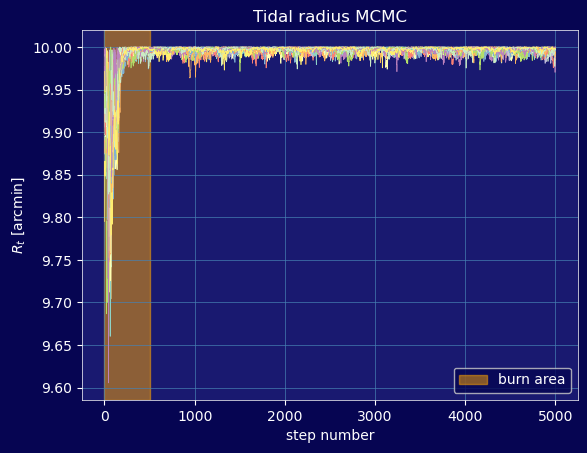

In [32]:
titles = ["Central surface density", "Core radius", "Tidal radius"]
variables = ["$\Sigma_0$", "$R_c$", "$R_t$"]
dimensions = ["stars/arcmin$^2$", "arcmin", "arcmin"]
for i in range(0, 3):
    plt.plot(samples[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{titles[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{variables[i]} [{dimensions[i]}]")
    plt.axvspan(0, n_burned_init, alpha=0.5, color='orange', label = "burn area")
    plt.legend()
    plt.show()


*(i) Based on the trace plots, choose one of the following and justify using your trace plots:*
- *My MCMC chains are well-converged and sampling from the posterior*
- *My MCMC chains are not converged in parameters [add the relevant parameters].*

*(ii) Did you leave enough steps for burn-in? Justify your answer based on the trace plots. If you chose too few burn-in steps, adjust your numbers and re-run the MCMC chains.*

**(i)**: My MCMC chains are well-converged and sampling from the posterior
- My chains are clearly converging, however the central and tidal radius appear better converged than the surface density (though this may be just a matter of scale.) All three plots tend to a single value after burn in and adhere to a consistent variance, with no visible drift or skew that might indicate sub-structures. 


**(ii)**: I did leave enough steps for burn-in. 
- Clearly, my MCMC ran far longer than it needed to in order to converge on a value after burn-in. However, better to be safe than sorry? I intended to burn 500 in my initial guess, however in reality that would be taking off some of the "good stuff", so I may take off a bit less than what I said (closer to 250-300). 

NOTE: For the surface density, the MCMC does indeed converge, but it converges at a value far higher than I guessed (and what I expected, given the initial distributions shown in Exercise 1.) It converged around a value of 80 arcmin, rather than the ~10.5 arcmin I expected and guessed. This means that my model is not good. I decided to investigate (not shown). One parameter I have had hard-coded for a while is the scale parameter in the log-likelihood. I decided to change this, thinking it (10) might be too large or too small. When I ran the chains with a scale parameter of 30, the surface density converged around 85/86 arcmin (so +6) and when I ran it with a scale parameter of 5, it converged around 65 arcmin (-15). What I believe this means is that the posterior is very sensitive to the prior and not being constrained enough by the data (Poisson likelihood). Thus, I am almost certain this means that the posterior is degenerate with the prior parameters, particularly the $R_c$, which I (have already stated previously) believe needs to be greater than 1 arcmin, and somewhere around 3 arcmin. I think this means there has to be some trade-off happening between $R_c$ and $\Sigma_0$ in the joint prior distribution. $R_c$ is too small, thus $\Sigma_0$ must blow up to compensate, or something of that nature. 

In [33]:
np.mean(sampler.acceptance_fraction)

0.54819

### 4.b. *Integrated autocorrelation time and effective sample size (after discarding burn-in!):*
*Compute the integrated autocorrelation time $\tau_{int}$ for each parameter and report the effective sample size $N_{eff} \approx N/\tau_{int}$. How long would you need to run your chain in order to achieve that sample? Justify your answers using the autocorrelation time. Hint: Most libraries have implemented a function to calculate the autocorrelation time, you shouldn’t need to write code for this yourself.*

Here I am re-running the emcee chain, this time using the burn-in feature (doing 300, which is less than I previously thought I needed but still a good chunk).

In [34]:
burn_in = 300
sampler = emcee.EnsembleSampler(n_walkers_init, n_dimensions, log_post)
print("Sampler Running")
sampler.run_mcmc(pos1, n_steps_init, progress = True)
samples_burned = sampler.get_chain(discard = burn_in, flat = False) 

Sampler Running


100%|██████████| 5000/5000 [00:31<00:00, 156.28it/s]


And just taking a look to make sure the burn-in was successfully filtered out:

MCMC Chains, Burn-out:


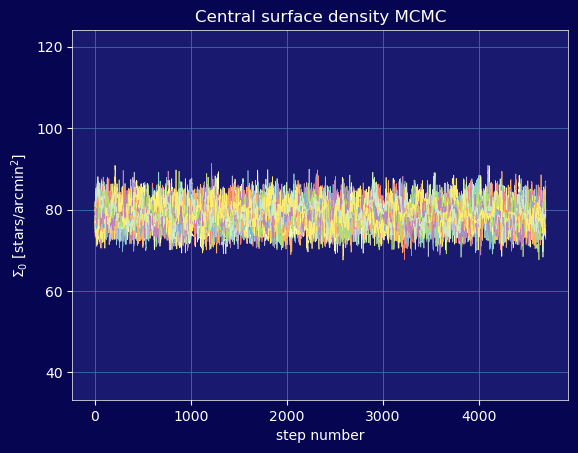

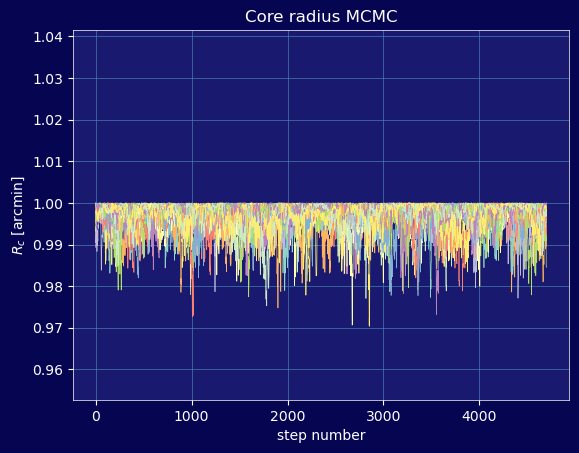

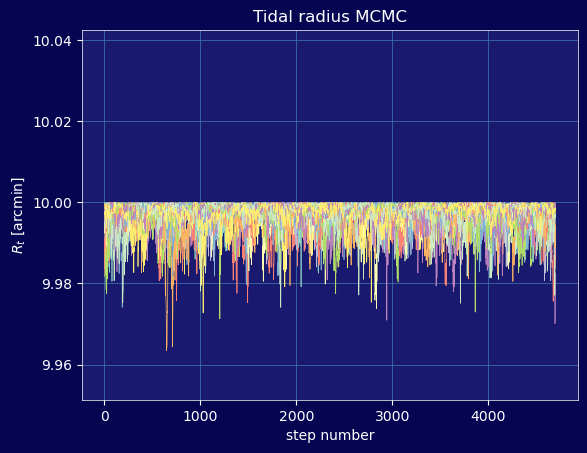

In [35]:
titles = ["Central surface density", "Core radius", "Tidal radius"]
variables = ["$\Sigma_0$", "$R_c$", "$R_t$"]
dimensions = ["stars/arcmin$^2$", "arcmin", "arcmin"]
print('MCMC Chains, Burn-out:')
for i in range(0, 3):
    plt.plot(samples_burned[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{titles[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{variables[i]} [{dimensions[i]}]")
    plt.ylim(np.mean(samples_burned[:,:,i]) - 15*np.std(samples_burned[:,:,i]), 
             np.mean(samples_burned[:,:,i]) + 15*np.std(samples_burned[:,:,i])) # just to see a bit better
    plt.show()

Then, in this next cell, I iterate through the three parameters to calculate the autocorrelation time $\tau$ for each, and then report these along with the effective sample size $N_{eff} \approx N/ \tau_{int}$ and the time I would need to achieve that sample size, which is equal to $\tau_{big} = N_{eff} \times \tau$. 

In [43]:
# Computing integrated autocorrelation time for each parameter
n_steps_burnout = n_steps_init - burn_in
taus = []
N_effs = []
taus_bigsample = []
for i in range(3): 
    tau = emcee.autocorr.integrated_time(samples_burned[:,:,i], c = 5, tol = 50, quiet = False)
    N_eff = n_steps_burnout/tau
    tau_bigsample = tau*n_steps_burnout
    # these will then be an array of times in order Sigma_0, R_c, R_t
    taus.append(tau) 
    N_effs.append(N_eff)
    taus_bigsample.append(tau_bigsample)

print(f'Autocorrelation Times:\n---------------------- \nSigma_0: {taus[0]} \nR_c: {taus[1]} \nR_t: {taus[2]}\n')
print(f'Effective Sample Sizes:\n----------------------- \nSigma_0: {N_effs[0]} \nR_c: {N_effs[1]} \nR_t: {N_effs[2]}\n')
print(f'Times to achieve N_eff:\n----------------------- \nSigma_0: {taus_bigsample[0]} \nR_c: {taus_bigsample[1]} \nR_t: {taus_bigsample[2]}')


Autocorrelation Times:
---------------------- 
Sigma_0: [40.97155227] 
R_c: [63.4613361] 
R_t: [56.36089912]

Effective Sample Sizes:
----------------------- 
Sigma_0: [114.71374014] 
R_c: [74.06084222] 
R_t: [83.39114658]

Times to achieve N_eff:
----------------------- 
Sigma_0: [192566.29565959] 
R_c: [298268.27969172] 
R_t: [264896.22586699]


### **3.c. Corner Plot**

*Make a corner plot of the parameters.*

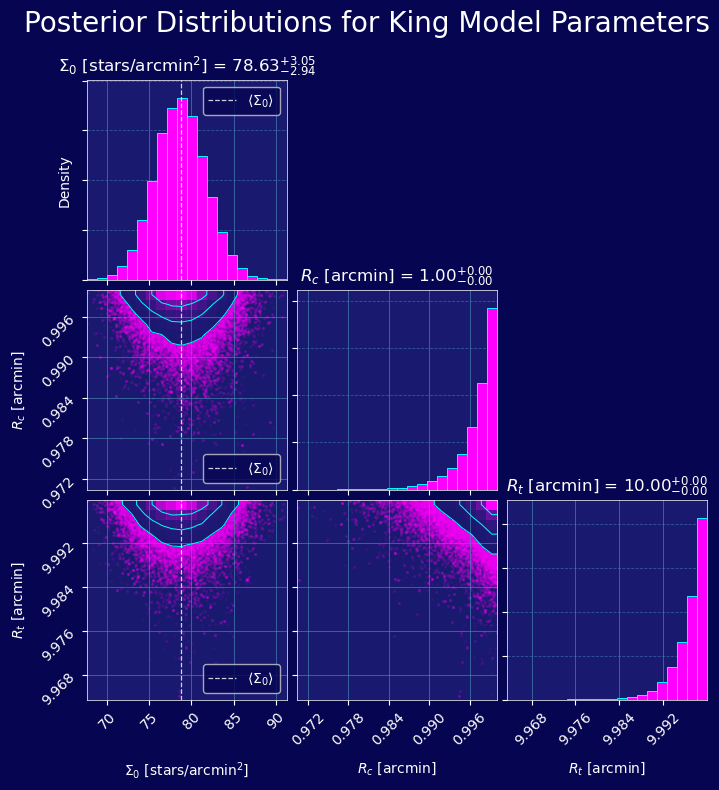

In [44]:
import corner
import matplotlib.ticker as mticker
samples_burned_flat = sampler.get_chain(discard = burn_in, flat = True) 
labels = ["$\Sigma_0$ [stars/arcmin$^2$]", 
          "$R_c$ [arcmin]", 
          "$R_t$ [arcmin]"]
fig = corner.corner(samples_burned_flat, labels = labels, show_titles = True, 
                    color="magenta",  # contours + hist edges
                    hist_kwargs={
                        "color": "magenta",
                        "linewidth": 0.7,
                        "histtype": "bar", 
                        "edgecolor": "cyan",
                    },
                    contour_kwargs={
                        "colors": ["cyan"],
                        "linewidths": 0.7
                    },
                    scatter_kwargs={
                        "s": 10,
                        "color": "cyan"
                    }
                )

fig.suptitle('Posterior Distributions for King Model Parameters', fontsize = 20, y = 1.04)

ndim = samples_burned_flat.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0,0].set_ylabel('Density')

axes[0,0].axvline(78.76, ls = 'dashed', alpha = 0.8, color = 'white', lw = 0.9, label = '$\langle \Sigma_0 \\rangle$')
axes[1,0].axvline(78.76, ls = 'dashed', alpha = 0.8, color = 'white', lw = 0.9, label = '$\langle \Sigma_0 \\rangle$')
axes[2,0].axvline(78.76, ls = 'dashed', alpha = 0.8, color = 'white', lw = 0.9, label = '$\langle \Sigma_0 \\rangle$')

axes[0,0].legend()
axes[1,0].legend(loc='lower right')
axes[2,0].legend(loc='lower right')


for i in range(ndim):
    ax = axes[i, i]

    # Force major y-ticks to exist
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))

    # Make sure grid is enabled for y
    ax.grid(True, axis="y", which="major", linestyle="--", alpha=0.6, zorder=0)

    # Draw grid above filled histogram
    ax.set_axisbelow(True)
    

# Force a draw so gridline artists are created
fig.canvas.draw()

plt.show()

 *Comment on the shape of the 1D and 2D posteriors: do they look Gaussian? Are they skewed? Are there multiple peaks for some of the parameters? Are there a lot of outliers from the distribution, or weird features? Are there parameters that are clearly correlated? Are all samples well-contained within the prior range, or are some truncated against the prior bounds? For each (unexpected) feature that you observe, give on one possible reason for what you see, and justify your answer based on any of your previous plots.*

#### 1D posteriors: 
**$\Sigma_0$:**
Sigma, like I saw in the MCMC chain plot, is convergent around a value of $\Sigma_0 = 78.76$ with quite normally distributed Gaussian noise (expected), no apparent skew nor is it being truncated. It looks like a perfect Gaussian. 

**$R_c$:**
$R_c$ is distributed in a half-Gaussian, stacked up against the starting point value (also the upper limit), with its peak density of around 0.994 occurring as high as possible, up against the right side of the grid (at 1), so skewed to the maximum of allowed values. 

**$R_t$:**
$R_t$ is also distributed in a half-Gaussian looking plot, where alike $R_c$ the highest density occurs at the maximum of the distribution, but at around 10. 

Both the peaks of $R_c$ and $R_t$ correspond to the upper bounds set by the log normal priors we set earlier, however they are clearly not well contained within those bounds. Thankfully there are not multiple peaks for any of the parameters, nor serious outliers in the distribution, only I would say a normal distribution out on the tails. However I think both of these distributions' shapes are a result of the fact that the priors themselves are too tightly constrained; as I said earlier, the central radius needs to be at least 3, but certainly not less than 1 – I believe that is exactly what is being represented here in the 1D posteriors. 

#### 2D posteriors: 

Both $R_c$ vs. $\Sigma_0$ and $R_t$ vs. $\Sigma_0$ are heavily smushed up against the upper limit I set in the original guesses (0.9999... and 9.9999...) as per the discussion of the 1D posteriors, but they are clearly also centered around the $\langle \Sigma_0 \rangle$ on the x-axis. 

$R_t$ vs. $\Sigma_0$: the posterior is heavily clustered and concentrated at a high values of $R_c$. $\Sigma_0$ varies along the $R_c$ axis, but has the highest variance when $R_c \approx R_{c,\max}$, and variance in $\Sigma_0$ decreases as $|R_t - R_{t,\max}|$. 

$R_c$ vs. $\Sigma_0$: we observe *almost* the same distribution as in the tidal radius $R_t$, however there is just a tiny bit of skewing. As in $R_t$ vs. $\Sigma_0$, variance decreases as $|R_c - R_{c,\max}|$ increases. *However*, as the central radius gets further away from its maximum, variance for values of $\Sigma_0$ *above* the average stay larger than those below. So the variance of $R_c$ decreases *more slowly* for higher values of $\Sigma_0$ than for lower. Thinking about this physically, the peak of the core radius distribution shifts higher for higher values of cluster surface density faster than it does after it drops lower than the mean. To me, this suggests that perhaps the underlying distribution resembles something more exponential than what is currently being modeled (i.e. maybe missing a power law in there). 

$R_c$ vs. $R_t$: these values are pushed into the high maximum allowed values for both parameters, clustered in the corner that represents these limits, and then stretched along a diagonal of 45 degrees. 

Overall, these 2D posteriors exhibit the radial constraints pushed against their upper bounds from the priors. $\Sigma_0$ seems to have some dependence on radii (in particular $R_c$), however in these distributions, the very dominant player is the truncation, and no significant tilt is visible. Rather, the priors are visible, and show that the data tends toward much larger scale radii than what is currently allowed under this posterior regime. 

### **4.d. *Posterior predictive checks:***
*Generate replicated datasets under your chosen likelihood using posterior draws. Note: to do this, first generate a model profile using a posterior sample, then use the distribution you’ve used to define the likelihood to add noise. Make PPC overlay plot: observed $N_j$, plus at least 20 replicated profiles. Are the replicated profiles similar to what you’ve observed? Can you see systematic biases (i.e. where the simulated profiles overestimate or underestimate the observed counts)? Does the noise distribution of your simulated data sets look similar to that of the data?*


In the following code, I am generating replicated datasets under the chosen likelihood (Poisson) using drawn values from the posterior. Some of this code is done using generative AI (ChatGPT, for help with the loops) but most of the code is mine. 

In [45]:
def posterior_predictive_check(posterior_sampler, burn_in, R_mid, Areas, n_draws = 20, seed = 33):

    # set seed
    rng = np.random.default_rng(seed) 
    # grab flattened samples
    posterior = posterior_sampler.get_chain(discard=burn_in, flat=True)
    # random sampling from posterior draws
    rand_idx = rng.choice(posterior.shape[0], size = n_draws, replace = False)
    thetas = posterior[rand_idx] # index the random draw, so this is a 1D array
    # replicated dataset 
    N_replicated = np.zeros((n_draws, len(R_mid)), dtype=int)
    
    for k, theta in enumerate(thetas):
        Sigma0, R_c, R_t = theta                  
        Sigma = sigma_king_cluster(R=R_mid, Sigma0=Sigma0, R_c=R_c, R_t=R_t)
        lambda_gen = Areas * Sigma
        N_replicated[k] = rng.poisson(lambda_gen)

    return thetas, N_replicated, posterior

def post_pred_check_plot(posterior_sampler, burn_in, R_mid, Areas, Ns, figsize, 
                         n_draws = 30, seed = 33): 
    
    # use the previous formula 
    thetas_ppc, N_replicated, posterior = posterior_predictive_check(posterior_sampler=posterior_sampler, 
                                                                     burn_in=burn_in, 
                                                                     R_mid = R_mid, 
                                                                     Areas = Areas,
                                                                     n_draws = n_draws, 
                                                                     seed = seed)
    # Real data, error bars
    N_err = np.sqrt(Ns)
    plt.figure(figsize=figsize)
    plt.errorbar(R_mid, Ns, yerr=N_err, capsize = 3, fmt="o", label="Observed $N_j$", color = 'cyan')

    # Replicated profiles
    plt.scatter(R_mid, N_replicated[0], label = '$N_j$ Simulated', color = 'magenta')
    for k in range(1, N_replicated.shape[0]):
        plt.scatter(R_mid, N_replicated[k], alpha=0.25, color = 'magenta')

    plt.xlabel("Radius [arcmin]")
    plt.ylabel("Counts per annulus $N_j$")
    plt.title("Posterior Predictive Check", size = 20)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.show()

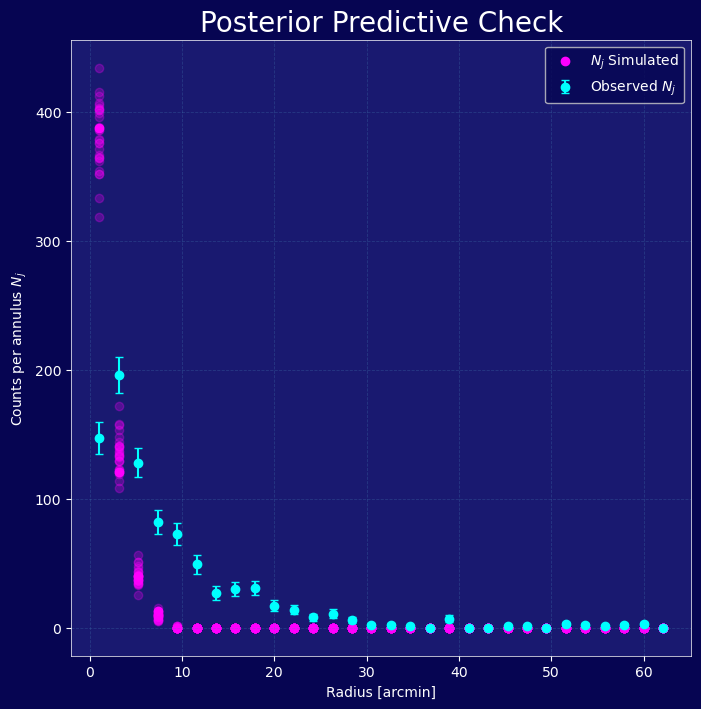

In [46]:
post_pred_check_plot(posterior_sampler=sampler, 
                     burn_in = 300, 
                     R_mid = R_mid_30, 
                     Areas = Areas_30, 
                     Ns = Counts_30, 
                     figsize = (8,8), 
                     n_draws = 30, 
                     seed = 33)

A few things stand out here. One is that yes, the replicated profiles are consistent with what I've seen in the posterior analysis, in that the posterior is not adequately representative of the data, whether from an issue with the likelihood or the priors. In terms of systematic biases, clearly the counts are much higher in the center than they should be (overestimation at minimum radius), and drop off much faster than the observed data (underestimation for $R > 5$ arcminutes). As for the noise distribution, it is hard to say if this looks similar to that of the data, since the fit is quite poor. I would argue that past $R = 10$ arcminutes, the simulated profiles are not noisy *enough*. 

### **4.e. *Posterior stats*** 
*Compute the posterior median and 68% credible interval for each parameter. Hint: the function np.percentile() makes this reasonably straightforward, as does arviz.summary()!*

In [47]:
# computing posterior median 
medians = []
credible_intervals = []
for i in range(3): 
    median = np.median(samples_burned[:,:,i])
    credible_int = np.percentile(samples_burned[:,:,i], [16, 50, 84])
    medians.append(median)
    credible_intervals.append(credible_int)

medians = np.array(medians)
credible_intervals = np.array(credible_intervals)

print(f'Sigma_0: \n------ \nMedian: {medians[0]} \nCredible Interval: {credible_intervals[0][0]} - {credible_intervals[0][2]}\n')
print(f'R_c: \n------ \nMedian: {medians[1]} \nCredible Interval: {credible_intervals[1][0]} - {credible_intervals[1][2]}\n')
print(f'R_t: \n------ \nMedian: {medians[2]} \nCredible Interval: {credible_intervals[2][0]} - {credible_intervals[2][2]}')

Sigma_0: 
------ 
Median: 78.63284765895409 
Credible Interval: 75.68788680146568 - 81.67894210209666

R_c: 
------ 
Median: 0.9980507062264214 
Credible Interval: 0.9947472226580004 - 0.999502190018101

R_t: 
------ 
Median: 9.99781346595102 
Credible Interval: 9.994365599069997 - 9.999434713234006


### **4.f. *Interpretation:*** 
*Based on the plots you’ve made above, discuss in a few sentences whether you think the posteriors you derived can be used to draw scientific conclusions about the cluster. Reference specific results/figures and the features you see in these figures in your answer.*

Based on the plots I've made above, I do not think the posteriors I have derived can be used to draw scientific conclusions about the cluster. I have kind of already discussed my thoughts on these things as follow-ups to the previous plots, but I can summarize here: 

The MCMC: for a good, representative chain, we want the sampler to converge on a value with a nice Gaussian distribution, a fuzzy but thin, vertically-constant caterpillar-like signal. This is what my $\Sigma_0$ chain does, however to a value far higher than what I guessed (and want). The $R_c$ and $R_t$ chains indeed converge, but against upper limits, above which the distribution (signal) does not exist; the noise looks Gaussian, but on only one side of this limit. Here, it seems like there are some degeneracies in posterior. Already, I do not trust the posterior. 

The posterior distribution plots: for me to be able to make scientific conclusions from a posterior, I would hope that the resulting 2D posteriors would be uniformly distributed, centered along both axes, perhaps with a little bit of correlation, but without significant skew. In all of the 2D plots, this is clearly not satisfied: all display very non-uniform distributions, suggesting that the underlying distributions exist outside of the scope of the bounds set by the posterior. Again, this suggests I should not derive scientific conclustions about my cluster from this posterior. 

The posterior predictive plot: after sampling from the posterior, I generate fake 20 fake profiles and compare these to the real count-profile ($N_j$ vs. $R$). In this plot, it appears that the posterior follows an underlying profile that is not representative of the data, and even the injected Poisson noise does not seem noisy enough. So again, this posterior is making a case to *not* be trusted for valid scientific conclusions! 

Posterior stats: $\Sigma_0$'s has a 68% credible interval perfectly centered on the median, a fine Gaussian spread. $R_c$'s median (~0.998 arcmin), however, like in the plots, is pinned up against the priors upper bound within the 68% CI (~0.9948 - ~0.9995 arcmin). It's piling up at the maximum, and the same goes for $R_t$, with its median (~9.9978) also pinned up at the maximum of the credible 68% interval (9.9945 - 9.9995 arcmin). 

In terms of "scientific conclusions," I guess one thing we can conclude is that the current combination of priors and likelihood do not successfully represent the real profile, suggesting a trade-off happening between the bounds placed on $\Sigma_0$ versus $(R_c,R_t)$, as the Poisson likelihood proved to be weak in relation to the priors when I switched around the scale parameter. I cannot make conclusions, but one thing I can see just by having eyes is that the cluster is very, very dense. I think that the model I have is just not adequate for this cluster specifically. I assume that I will better resolve this in the next section! 

## 5: Priors Revisited

### **5.a. *Reasonable Priors***

*Based on the results from the previous part, discuss whether the initial priors are a reasonable choice, what kind of adjustment you might make to improve them, and how you expect that adjustment to affect the diagnostics you computed in the previous section.*

Based on the results from the previous part, I do not believe the initial priors are a reasonable choice, but not everything about them needs to change. Firstly, in construction, I think that 
- $\Sigma_0$ being a log half-normal distribution should remain, based on the very initial distribution we observed for surface density vs. radius (Exercise 1). I also think the scale parameter of order 10 should remain; I do not think this prior was the problem
- $R_c$'s prior is clearly messing up a lot, considering also that $R_t$ is conditional upon it (but $R_t$ still has other issues). I think that allowing $R_c$ to adhere to a range greater than 1 in its prior would greatly improve the predictive power of my setup. I estimated that the $R_c$ should be around 3 arcmins, based on where in the plot from Exercise 1 ($\Sigma_0 vs. R_c$) the surface density drops to half of the maximum. So, before I get to technical and confused in this answer, simply put: I need to increase the upper bound of $R_c$. This is clear from the plots and the general statistics. 
- $R_t$'s prior also is being heavily constricted as seen in the corner plots. Clearly, the upper bound on this prior also needs to increase. Of course $R_t$ will still need to be greater than $R_c$ and that should not change. However I wonder here, if it would be useful to instead of having $R_t$ be conditional on $R_c$, it could work to have $R_t$ vary up to the maximum radius of the cluster and then impose that $R_c$ must be smaller. I do not know what that looks like in practice. 

I would expect that these adjustments would lead to the MCMC chains all converging with a proper Gaussian noise (rather than with one side chopped); the 1D posteriors thus should all be Gaussian, with the 2D posteriors mostly uniform (unless there is some kind of correlation that is actually related to the physical attributes of the cluster, and not an issue with the bounds.) Also hopefully, if I do this, the posterior predictive plot would... line up nicely :D

One thing I want to note here, as an aside -- in all of this thinking about the normal vs. log-normal posterior, it also occurred to me that one of my biggest fears could be playing a role: I did not choose enough bins. I chose 30 by eye-balling the point at which the counts drop to zero in the 50-bin version (which was at 25, and I added an extra 5 bins for breathing room.) Now with this knowledge of the log-normal, I postulate that having more bins (even just sticking with the 50) would have led to a slightly better fit for the posterior predictive check, even though it still would have likely been not great. However, even without this understanding, I failed to recognize something far more mundane: my cluster is *really* dense in the center. Most of the 845 stars are positioned within the innermost third of the entire radial range, and drop off quite sharply. This means that when I used 30 bins instead of say, 40 or even 60, closer in bin-size to the 15 I determined was too little, I was *really* sacrificing resolution at very low $R$. Obviously the prior was problematic, but I do believe my binning choice also played a role. If I had more time, I would go back and redo this, but unfortunately I don't, and the 30-bin numbers are hard-coded in a way that would confuse me too much. But this is just a thought. 

### 5.b. Prior Choices

*Here are three possible choices for the prior for core radius $r_c$:*
- *$r_c ∼ \text{Uniform}(0, 0.5)$*
- *$r_c ∼ \text{Log-Uniform}(-5, \log 2r_t)$*
- *$r_c ∼ \text{Uniform}(0, R_{max})$ where $R_{max}$ is the largest bin size*

*Rank the three options from most to least appropriate, and justify your rankings in a short paragraph. Your justification must reference the properties of your dataset (e.g. bin widths, $R_{max}$) and what the parameters represent (which will help you exclude unphysical choices).*

My ranking: 
- **Most Appropriate**: $r_c ∼ \text{Uniform}(0, R_{max})$ where $R_{max}$ is the largest bin size
- **Sort of Appropriate**: $r_c ∼ \text{Log-Uniform}(-5, \log 2r_t)$
- **Least Appropriate**: $r_c ∼ \text{Uniform}(0, 0.5)$

My justification: 

**Most Appropriate**

As I just explained in the previous question, the goal is to release the bounds of the core radius from the brutal confines of [0, 1). Because I still do not know that much about my cluster (and cannot assume), I think that the most liberal approach is the best approach, which here suggests a uniform distribution from 0 to $R_{max}$ where $R_{max}$ is defined as the largest bin size. This being the upper bound makes sense as there can be no $R_c$ that is bigger than the radius of the largest annuli -- that would be unphysical and wrong, and this makes sure that the model can't place scales in places where the data does not exist. Building the prior like this is building a *weakly informative prior*, which is what I want after seeing what a strongly informative prior was doing in the last go of things. 

Also, having it be just a uniform distribution rather than a log-uniform is more appropriate for my cluster. The log-uniform distribution makes sure that equal weighting is given to multiple orders of magnitude. This is good when something like radius is unknown over multiple orders of magnitude, however in this construction that's not the case. The way that we set up the data is with bins of finite resolution. If there are $R_c$ that are much smaller than the innermost bin, they cannot be distinguished (could lead to stacking at very small values). So a uniform rather than log uniform in $R_c$ avoids putting a ton of weight on the small and unresolved things happening within the innermost bin, and allows the posterior to explore the full, less-constricted range. In this sense: I know the scale (OOM), so I don't need to be super liberal there, but I still need a pretty weak prior, so a uniform prior works best, and in this case, might be more conservative in the scale than the the previous log prior, but that conservatism is offset by the upper bound of $R_{max}$. 

**Sort of Appropriate** 

This log-uniform prior could work, and it does satisfy some requirements -- having there be a dependence between $R_c$ and $R_t$, and this is a very loose bound given that the limit of the allowed $R_c = 2R_t$. However, having the lower bound in log-space be -5 arcmin means that the smallest $R_c$ allowed would be on order $10^{-3}$ arcmin which is much, much smaller than my smallest bin (~4.2) arcmins. And like I discussed in the previous explanation, the log-uniform distribution can place a lot of weight on possible values of $R_c$ smaller than the bins I have, which could lead to sharp stacking and resolution that gets lost with my bins. The tiny scales, as I've noted even in the posterior predictive check plot: there is too much going on at small $R$, whereas the actual profile itself is a bit slower in its descent. That would make this choice a bit less preferable. 

Note: now I am a bit confused. I think this analysis holds, but considering this whole thing is in log, then the log of a log-uniform would just be uniform in the end? Or would that double-down on the order of magnitude dependency here and even further skew the results? This, I am not sure. 

**Least Appropriate**

For all of the reasons that have already been discussed, having a distribution at this scale would only worsen the problems that have shown up in my plots thus far, given that this range is even smaller than the previous (0,0.5). 


### **5.c. *$R_t$***
*First check whether your cluster has a Wikipediai page, with a tidal radius and distance given. If so, note the the given tidal radius and its uncertainty (and include the reference page where you obtained the information), then translate both into arcmin using*
$$
\text{arcmin} = \frac{\text{size}}{\text{distance}} \times \frac{180}{\pi} \times 60
$$

*and use these values to define a Gaussian prior for $R_t$. If you can’t find any values for your cluster, define a reasonably conservative prior based on radial profile and justify your choice using specific observations from previous figures you’ve made.*

On the Wikipedia page for NGC 2658, there is no tidal radius given, but there is an apparent size, at 10', however no uncertainty is reported. This would put the tidal radius at 5 arcmin. Just by looking at the cluster, it appears the outer stars are bound at a larger distance than 5 arcmin. I was going to use the Wikipedia size as a proxy, but that feels wrong given that I can actually use the maximum bin-radius instead. I am going to set the prior at around 60 (will be ```R_max```) arcminutes and allow for a standard deviation of $0.5R_{max}$ for a more conservative distribution. So, I am defining the $R_t$ prior: 

$$
R_t \sim \text{Normal}(\mu = R_{max}, \sigma = \frac{1}{2}R_{max})
$$

### **5.d. *New Priors***
*Implement your new priors, re-run your MCMC chain and compute the same diagnostics as before.*

*(i) Is the MCMC sampler converged? Use the numbers and Figures to justify your answer.*

*(ii) Comment on any surprising features in the corner plot that you’ve made, and name one reason per feature you identify that could explain them.*

*(iii) Is the posterior predictive distribution a better approximation to the real data than for the previous prior? What has changed? Are there features in the data that are still not well-explained by the model? Highlight specific features in the Figure to justify your argument.*

*(iv) Compute posterior medians and credible intervals for all parameters, and compare these to the posterior medians and credible intervals computed on the MCMC chains using the previous priors. Have any parameter estimates shifted? In which direction? State what change in the prior you think has the largest effect on the results.*

First, I am going to rewrite my functions to account for these changes. 

In [70]:
def log_gaussian(x, mu, sigma):
    """
    Log-pdf of a Normal (Gaussian) distribution.

    Parameters
    ----------
    x : float or np.ndarray
        Point(s) at which to evaluate the log-density.
    mu : float
        Mean of the Normal distribution.
    sigma : float
        Standard deviation of the Normal distribution. Must be > 0.

    Returns
    -------
    logp : float or np.ndarray
        Log-density evaluated at `x`. Returns `-np.inf` where parameters
        are invalid (e.g., sigma <= 0) or where evaluation is undefined.
    """
    x = np.asarray(x)
    if not np.isfinite(mu) or not np.isfinite(sigma) or sigma <= 0:
        return np.full_like(x, -np.inf, dtype=float) if x.ndim else -np.inf

    z = (x - mu) / sigma
    logp = -0.5 * (np.log(2.0 * np.pi) + 2.0 * np.log(sigma) + z**2)
    return logp


# Log priors 
# Sigma_0 is same: the log half-normal
# R_c is not new in structure: log-Uniform, but different in bounds
# R_t is also new: log-Gaussian. 

# define inputs
R_max = np.max(R_mid_30) # upper bound


# so here using R_max for both priors 

def Rc_prior_new(Rc_guess): 
    Rc_log_uniform = log_uniform(Rc_guess, 0, R_max)
    return Rc_log_uniform 

def Rt_prior_new(Rt_guess): 
    Rt_log_gaussian = log_gaussian(Rt_guess, R_max, 0.33*R_max)
    return Rt_log_gaussian 

def joint_prior_prob_new(theta, sigma_scale): 
    '''
    Function computes the new version of joint prior probability of the parameters of central surface density, core radius and tidal radius 
    based on inputs of parameter guesses and the pre-decided scale for Sigma. 

    Parameters 
    ----------
    theta :  np.ndarray -- an array of values in order 1) central surface density, 2) 
             core radius, 3) tidal radius

    sigma_scale : float -- this is a necessary input for the half-normal distribution, 
                  for which I am typically going to use a value of 10 given 
                  an explanation above. 
                 
    Returns
    -------
    prior: float -- value of the joint probability for a given set of input parameters

    '''

    Sigma0, R_c, R_t = theta
    log_joint_prob = sigma_prior(Sigma0, sigma_scale) + Rc_prior_new(R_c) + Rt_prior_new(R_t)
    return log_joint_prob

def new_log_post(theta): 

    '''
    Function will take the input of values for the new joint_prior_prob and 
    convert_sigma_poisson_loglikely, hard-coding certain parameters
    and compute the log posterior based on these two computations
    
    Parameters
    ----------
    
    theta : numpy.ndarray
        to be inputted during fitting, array including (in order) 
        central surface density, core radius and tidal radius             

    Returns
    -------
    log_posterior : the log posterior for the given input parameters 
    
    '''
    
    # here, hard-coding parameters 
    sigma_scale = 10
    R_mid = R_mid_30
    Areas = Areas_30
    Ns = Counts_30

    # define factors 
    log_joint_prior = joint_prior_prob_new(theta, sigma_scale) # changing to new
    if not np.isfinite(log_joint_prior):
        return -np.inf # debugging purposes 
    log_likelihood = convert_Sigma_poisson_loglikely(theta, R_mid, Areas, Ns)
    
    # compute posterior 
    log_posterior = log_likelihood + log_joint_prior

    return log_posterior

So, the following cell will do all of the following: 
1. set parameters for MCMC
2. choose starting positions
3. randomize the starting positions for the MCMC
4. run the MCMC
5. plot the chains with burn-out
6. do the autocorrelation calculations. 

Initial Parameters for MCMC: 
----------------------------
Walkers: 20
Steps per chain: 5000
Burned steps per chain: 300
Total Steps: 100000
Sampler Running


100%|██████████| 5000/5000 [00:41<00:00, 121.23it/s]


MCMC Chains, Burn-out:


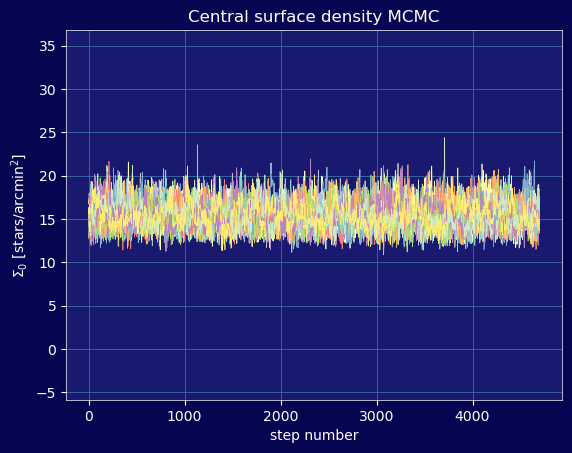

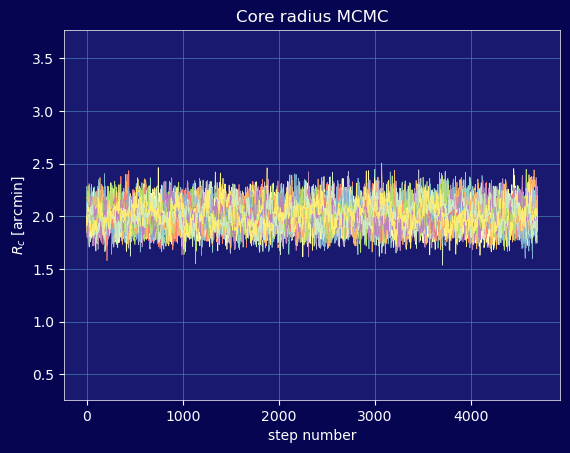

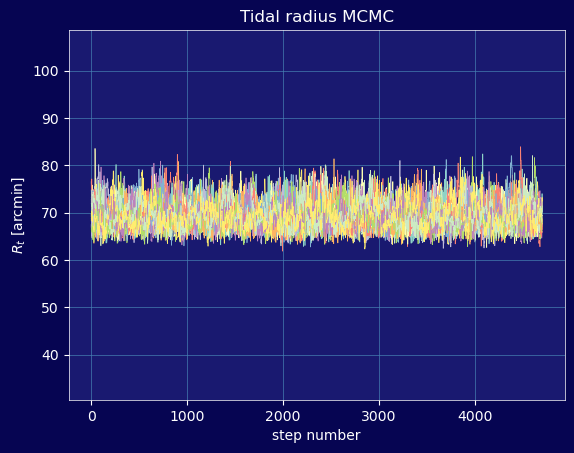

Autocorrelation Times:
---------------------- 
Sigma_0: [40.95635302] 
R_c: [40.25708459] 
R_t: [34.67264083]

Effective Sample Sizes:
----------------------- 
Sigma_0: [114.75631138] 
R_c: [116.7496367] 
R_t: [135.55356291]

Times to achieve N_eff:
----------------------- 
Sigma_0: [192494.8591927] 
R_c: [189208.29755509] 
R_t: [162961.41189994]


In [71]:
# ------ same parameters as previous except for new burn in  ------ 
n_dimensions = 3 # for the three theta values
n_walkers_init = 20 # number of chains
n_steps_init = 5000 # steps per chain 
n_burned_init = 300 # burn in steps 
total_steps = n_steps_init * n_walkers_init
print('Initial Parameters for MCMC: \n----------------------------')
print(f'Walkers: {n_walkers_init}')
print(f'Steps per chain: {n_steps_init}')
print(f'Burned steps per chain: {n_burned_init}')
print(f'Total Steps: {total_steps}')

# ------ choosing starting position ------ 
sigma_30 = Counts_30 / Areas_30
sigma_30_bg = np.mean(sigma_30[-5:])
sigma_0_guess = np.max(sigma_30 - sigma_30_bg)
# THIS IS NEW 
# first position guesses: 
first_pos_guesses = np.array([sigma_0_guess, 3, R_max]) 

# ------ define new randomizer ------  

rng = np.random.default_rng(44)
def get_randomized_inf_check_new(starting_theta, n_walkers, n_dims):
    '''Just making this in case I need to re-generate the random sample with different emcee params
    COME BACK AND ANNOTATE THIS FUNCTION
    '''
    # randomize position
    position = starting_theta + 0.1*rng.standard_normal(size=(n_walkers, n_dims)) # variance of 10^-2

    # this is a little while bit that makes sure things are within the bounds of the prior
    # and resamples if it has an infinite output 
    out_of_bounds = ~np.isfinite([joint_prior_prob_new(pos, 10) for pos in position])
    while np.any(out_of_bounds): # this just makes sure 
        position[out_of_bounds] = starting_theta + 0.1 * rng.standard_normal(size = (out_of_bounds.sum(), n_dims))
        out_of_bounds = ~np.isfinite([joint_prior_prob_new(pos, 10) for pos in position])
    
    return position

# try out randomizer
pos1 = get_randomized_inf_check_new(first_pos_guesses, n_walkers_init, n_dimensions)

# ------ Run MCMC ------ 
sampler = emcee.EnsembleSampler(n_walkers_init, n_dimensions, new_log_post)
print("Sampler Running")
sampler.run_mcmc(pos1, n_steps_init, progress = True)
samples = sampler.get_chain(discard = 0, flat = False)

# ------ plot the burned chains ------ 
samples_burned_2 = sampler.get_chain(discard = burn_in, flat = False) 
titles = ["Central surface density", "Core radius", "Tidal radius"]
variables = ["$\Sigma_0$", "$R_c$", "$R_t$"]
dimensions = ["stars/arcmin$^2$", "arcmin", "arcmin"]
print('MCMC Chains, Burn-out:')
for i in range(0, 3):
    plt.plot(samples_burned_2[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{titles[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{variables[i]} [{dimensions[i]}]")
    plt.ylim(np.mean(samples_burned_2[:,:,i]) - 15*np.std(samples_burned_2[:,:,i]), 
             np.mean(samples_burned_2[:,:,i]) + 15*np.std(samples_burned_2[:,:,i])) # just to see a bit better
    plt.show()

# ------ do autocorrelation calculations ------ 

n_steps_burnout = n_steps_init - burn_in
taus = []
N_effs = []
taus_bigsample = []
for i in range(3): 
    tau = emcee.autocorr.integrated_time(samples_burned_2[:,:,i], c = 5, tol = 50, quiet = False)
    N_eff = n_steps_burnout/tau
    tau_bigsample = tau*n_steps_burnout
    # these will then be an array of times in order Sigma_0, R_c, R_t
    taus.append(tau) 
    N_effs.append(N_eff)
    taus_bigsample.append(tau_bigsample)

print(f'Autocorrelation Times:\n---------------------- \nSigma_0: {taus[0]} \nR_c: {taus[1]} \nR_t: {taus[2]}\n')
print(f'Effective Sample Sizes:\n----------------------- \nSigma_0: {N_effs[0]} \nR_c: {N_effs[1]} \nR_t: {N_effs[2]}\n')
print(f'Times to achieve N_eff:\n----------------------- \nSigma_0: {taus_bigsample[0]} \nR_c: {taus_bigsample[1]} \nR_t: {taus_bigsample[2]}')


#### **5.d.i**

The MCMC sampler is indeed converged on all three parameters, given that (in the chain plots) the chains all reach stationary states where no clear drift or trends appear and remain in an enclosed range. The integrated correlation times (as of last run) also are within 50% of my set tolerance (50). Multiplying $\tau \times N_{eff}$ for each parameter, I get around 4600, which is around the number of steps I have per chain, after burn-out (4700), so this is good. 

The next cell will then plot the corner plot as well as the posterior predictive check: 

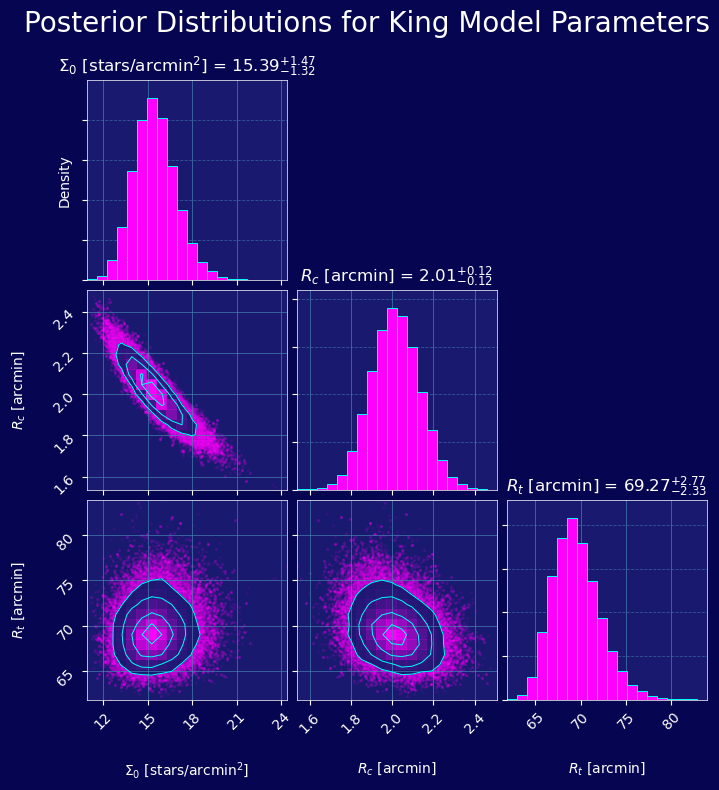

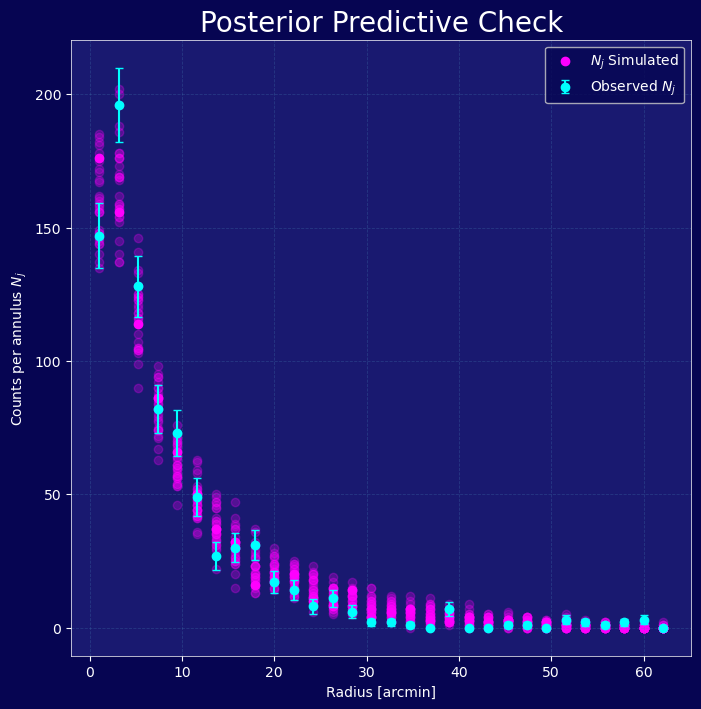

In [73]:
import matplotlib.ticker as mticker
samples_burned_flat = sampler.get_chain(discard = burn_in, flat = True) 
labels = ["$\Sigma_0$ [stars/arcmin$^2$]", 
          "$R_c$ [arcmin]", 
          "$R_t$ [arcmin]"]
fig = corner.corner(samples_burned_flat, labels = labels, show_titles = True, 
                    color="magenta",  # contours + hist edges
                    hist_kwargs={
                        "color": "magenta",
                        "linewidth": 0.7,
                        "histtype": "bar", 
                        "edgecolor": "cyan",
                    },
                    contour_kwargs={
                        "colors": ["cyan"],
                        "linewidths": 0.7
                    },
                    scatter_kwargs={
                        "s": 10,
                        "color": "cyan"
                    }
                )

fig.suptitle('Posterior Distributions for King Model Parameters', fontsize = 20, y = 1.04)

ndim = samples_burned_flat.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0,0].set_ylabel('Density')

for i in range(ndim):
    ax = axes[i, i]

    # Force major y-ticks to exist
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))

    # Make sure grid is enabled for y
    ax.grid(True, axis="y", which="major", linestyle="--", alpha=0.6, zorder=0)

    # Draw grid above filled histogram
    ax.set_axisbelow(True)
    

# Force a draw so gridline artists are created
fig.canvas.draw()

plt.show()

post_pred_check_plot(posterior_sampler=sampler, 
                     burn_in = 300, 
                     R_mid = R_mid_30, 
                     Areas = Areas_30, 
                     Ns = Counts_30, 
                     figsize = (8,8), 
                     n_draws = 30, 
                     seed = 33)


#### **5.d.ii**

Surprising features: 
At this point, I am not really surprised by much when it comes to the things my own convoluted code *might* produce. However, there are some things that stand out (corner plot)! 

**1) $R_c$ vs. $\Sigma_0$:** there is heavy correlation in this 2D posterior, forming a kind of banana shape. The banana shape implies that there is not only correlation, but that there is a *nonlinear* correlation between the two parameters. I think this means that for a lot of different combinations of $\Sigma_0$ and $R_c$, the likelihood is the same; the Poisson likelihood gives a distribution from the data, but the data itself cannot alone distinguish or constrain these two parameters. In another lens: I was having problems before because there was a trade-off occuring between the core radius (which was being to strictly constrained) and the central surface density. The $R_c$ was too small, so $\Sigma_0$ was blowing up to compensate in the inner-bins, and this still technically worked, which allowed the MCMC to converge. I think that trade-off relationship is what is visible in this banana, but here we're now seeing the case where $\Sigma_0$ is too small, so $R_c$ increases to compensate. In terms of its nonlinearity, this is intuitive given that in the King Profile which has been used here, surface density $\Sigma$ itself depends on a *nonlinear* combination of $\Sigma_0$ and $R_c$ (I think $\Sigma(R) \propto \Sigma_0 R_c^2)$, and given that the entire radial profile acts like this, the banana shape also makes sense. 

Also (last thing) I remember in the previous corner plot (with messed up priors) that there was a *tiny* bit of skewing in the variance of $\Sigma_0$ as values of $R_c$ got further from the limit; even with a weak likelihood, that relationship was still peeking through. But hence I think this banana is also proof that here, the posterior is far more data driven, which we want. 

**2) Skewing in $R_t$:** up until Exercise 5, I did not care much about the tidal radius. However, I see that its distribution is skewed with a longer tail towards higher values. This is also(!) noticeable in the MCMC chain plot for $R_t$, which shows that after it converges, it has a higher noise amplitude above the mean than below the mean. But I'm almost certain that this *should* be the case: I set the peak of the Gaussian to be exactly at the maximum projected radius ($R_{max}$) in the stellar set, which means that below $R_{max}$ there is a lot of real data to verify the walkers of the MCMC, but above $R_{max}$, data itself is much less able to constrain the tidal radius and the walkers can go a bit higher before being constrained. 

Otherwise: the 1D posteriors all appear to be roughly Gaussian, and both $R_t$ vs. $\Sigma_0$ and $R_t$ vs. $R_c$ are slightly skewed but mainly quite uniform in distribution. 



#### **5.d.iii** 
The posterior predictive distribution is indeed a better approximation to the real data than the previous prior! 
Between the previous plot and this one, what has changed? 
- the simulated profiles follow a shallower descent from the maximum, and follow a shape that resembles the real data 
- the real data points are actually all contained within the spreads of the simulated data (however the peak $N_j$ at 5 arcminutes has an error bar which extends beyond the simulated spread) but overall the new profile fits quite nicely! 
- even the smaller-scale distributions which I was worried about with my binning, at very small R, are actually captured (the increase from the first to second bin, so peak density occurs technically outside the very center)
- the variance of the simulated data also is roughly adequate to hold the error bars of the observed data as well (whereas before I felt that the simulated data was not disperse enough) 
At this point, it appears that most features are well-explained by the model, and overall, I am quite pleased with this outcome. 

#### **5.d.iv.**

In [74]:
# computing posterior median 
medians_2 = []
credible_intervals_2 = []
for i in range(3): 
    median = np.median(samples_burned_2[:,:,i])
    credible_int = np.percentile(samples_burned_2[:,:,i], [16, 50, 84])
    medians_2.append(median)
    credible_intervals_2.append(credible_int)

medians_2 = np.array(medians_2)
credible_intervals_2 = np.array(credible_intervals_2)

In [75]:
# print stats
print('Sigma_0 \n-------')
print(f'Median Previous: {medians[0]} \nCredible Interval Previous: {credible_intervals[0][0]} - {credible_intervals[0][2]} (Width = {np.abs(credible_intervals[0][0] - credible_intervals[0][2]):.2f})')
print(f'Median Now: {medians_2[0]} \nCredible Interval Now: {credible_intervals_2[0][0]} - {credible_intervals_2[0][2]} (Width = {np.abs(credible_intervals_2[0][0] - credible_intervals_2[0][2]):.2f})')
print(f'Change in Median: {np.abs(medians[0] - medians_2[0])}\n')

print('R_c \n---')
print(f'Median Previous: {medians[1]} \nCredible Interval Previous: {credible_intervals[1][0]} - {credible_intervals[1][2]} (Width = {np.abs(credible_intervals[1][0] - credible_intervals[1][2]):.3f})')
print(f'Median Now: {medians_2[1]} \nCredible Interval Now: {credible_intervals_2[1][0]} - {credible_intervals_2[1][2]} (Width = {np.abs(credible_intervals_2[1][0] - credible_intervals_2[1][2]):.2f})')
print(f'Change in Median: {np.abs(medians[1] - medians_2[1])}\n')

print('R_t \n---')
print(f'Median Previous: {medians[2]} \nCredible Interval Previous: {credible_intervals[2][0]} - {credible_intervals[2][2]} (Width = {np.abs(credible_intervals[2][0] - credible_intervals[2][2]):.2f})')
print(f'Median Now: {medians_2[2]} \nCredible Interval Now: {credible_intervals_2[2][0]} - {credible_intervals_2[2][2]} (Width = {np.abs(credible_intervals_2[2][0] - credible_intervals_2[2][2]):.2f})')
print(f'Change in Median: {np.abs(medians[2] - medians_2[2])}\n')

Sigma_0 
-------
Median Previous: 78.63284765895409 
Credible Interval Previous: 75.68788680146568 - 81.67894210209666 (Width = 5.99)
Median Now: 15.388700881929626 
Credible Interval Now: 14.072612837281515 - 16.857356483876696 (Width = 2.78)
Change in Median: 63.24414677702447

R_c 
---
Median Previous: 0.9980507062264214 
Credible Interval Previous: 0.9947472226580004 - 0.999502190018101 (Width = 0.005)
Median Now: 2.012138749788071 
Credible Interval Now: 1.8966011027530227 - 2.1306585611145157 (Width = 0.23)
Change in Median: 1.0140880435616495

R_t 
---
Median Previous: 9.99781346595102 
Credible Interval Previous: 9.994365599069997 - 9.999434713234006 (Width = 0.01)
Median Now: 69.27235862635682 
Credible Interval Now: 66.94248268115665 - 72.04012100974307 (Width = 5.10)
Change in Median: 59.2745451604058



Parameter estimates have definitely shifted. I'm sorry for the results printed above the way that they are, quite clunky. The width of the credible interval for $\Sigma_0$ decreased from 5.96 to 2.83 (so about 3, exact results dependent on MCMC obviously). The credible intervals for both $R_c$ and $R_t$ increased in width, however that is a result of the initial priors being off resulting in piling up at the limits. The decrease in CI for $\Sigma_0$ indicates the posterior is less spread out over the range containing 68% of the probability distribution, which means more certainty, which is good! 

Given what I have observed over the course of this assignment and in the highly correlated relationship between $\Sigma_0$ and $R_c$, I do think that changing the prior for $R_c$ (releasing it from below 1 arcminute) had the largest effect on results. I also believe this because when I was messing around with the priors, changing the prior for $R_t$ really did not change much about the convergence of the other two. This also is intuitive given how densely packed the cluster is at its center, which we now see does technically extend to 2 arcminutes rather than 1. 

Final thoughts: 

- I think I am now grasping the balance between priors and likelihood. I had a hard time with it during lecture, so it is just so great to be able to learn in a hands-on way like this. It is a lot easier to *see*. I didn't quite understand the tradeoff between choice of priors, either, and this has helped a lot. 
- It is very satisfying that, not only did my posterior predictive sample follow the shape of the original profile, but managed to contain all of the original points within its spread. Yay! (I hope this is the case when this notebook is run during grading.) 

Thank you for your patience (in this notebook and otherwise) !!!

# WORKS BELOW THIS POINT: 

In [62]:
# same parameters as previous except for new burn in
n_dimensions = 3 # for the three theta values
n_walkers_init = 20 # number of chains
n_steps_init = 5000 # steps per chain 
n_burned_init = 300 # burn in steps 
total_steps = n_steps_init * n_walkers_init
print('Initial Parameters for MCMC: \n----------------------------')
print(f'Walkers: {n_walkers_init}')
print(f'Steps per chain: {n_steps_init}')
print(f'Burned steps per chain: {n_burned_init}')
print(f'Total Steps: {total_steps}')

# choosing starting position
sigma_30 = Counts_30 / Areas_30
sigma_30_bg = np.mean(sigma_30[-5:])
sigma_0_guess = np.max(sigma_30 - sigma_30_bg)
# THIS IS NEW 
# first position guesses: 
first_pos_guesses = np.array([sigma_0_guess, 3, R_max]) 


Initial Parameters for MCMC: 
----------------------------
Walkers: 20
Steps per chain: 5000
Burned steps per chain: 300
Total Steps: 100000


In [63]:
# define new randomizer 

rng = np.random.default_rng(44)
def get_randomized_inf_check_new(starting_theta, n_walkers, n_dims):
    '''Just making this in case I need to re-generate the random sample with different emcee params
    COME BACK AND ANNOTATE THIS FUNCTION
    '''
    # randomize position
    position = starting_theta + 0.1*rng.standard_normal(size=(n_walkers, n_dims)) # variance of 10^-2

    # this is a little while bit that makes sure things are within the bounds of the prior
    # and resamples if it has an infinite output 
    out_of_bounds = ~np.isfinite([joint_prior_prob_new(pos, 10) for pos in position])
    while np.any(out_of_bounds): # this just makes sure 
        position[out_of_bounds] = starting_theta + 0.1 * rng.standard_normal(size = (out_of_bounds.sum(), n_dims))
        out_of_bounds = ~np.isfinite([joint_prior_prob_new(pos, 10) for pos in position])
    
    return position

# try out randomizer

pos1 = get_randomized_inf_check_new(first_pos_guesses, n_walkers_init, n_dimensions)



In [64]:
pos1

array([[10.70044085,  3.01023051, 63.18873622],
       [10.66949082,  3.08242439, 63.21395659],
       [10.51792752,  2.89811264, 63.19367783],
       [10.50464863,  3.08272349, 63.17718638],
       [10.48131514,  3.02677253, 63.22697899],
       [10.57359659,  2.92174309, 63.18229384],
       [10.59154475,  3.08242874, 63.22826438],
       [10.46501883,  2.95022286, 63.21663225],
       [10.38607672,  3.07772288, 63.07211595],
       [10.51366701,  3.14433399, 63.14961265],
       [10.52565666,  3.02814131, 63.14666645],
       [10.49325367,  3.02498575, 63.36974392],
       [10.64780765,  3.04379057, 63.18178936],
       [10.63562348,  3.06240881, 63.07038738],
       [10.60655037,  3.00522379, 63.32764661],
       [10.53473697,  3.12517618, 63.04049246],
       [10.58713584,  2.92885592, 63.06832306],
       [10.63437685,  2.90168572, 63.14224998],
       [10.48564618,  3.03959209, 63.18382281],
       [10.33936647,  3.07012877, 63.09512212]])

In [65]:

# this block I am using with the help of my friend and classmate, Ana Mare

sampler = emcee.EnsembleSampler(n_walkers_init, n_dimensions, new_log_post)
print("Sampler Running")
sampler.run_mcmc(pos1, n_steps_init, progress = True)
samples = sampler.get_chain(discard = 0, flat = False)

Sampler Running


100%|██████████| 5000/5000 [00:41<00:00, 119.76it/s]


MCMC Chains, Burn-out:


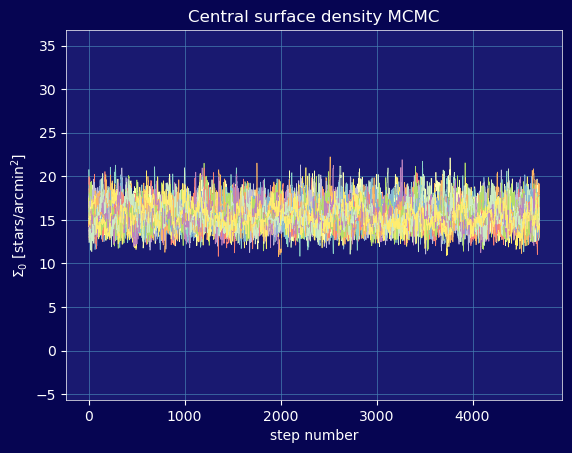

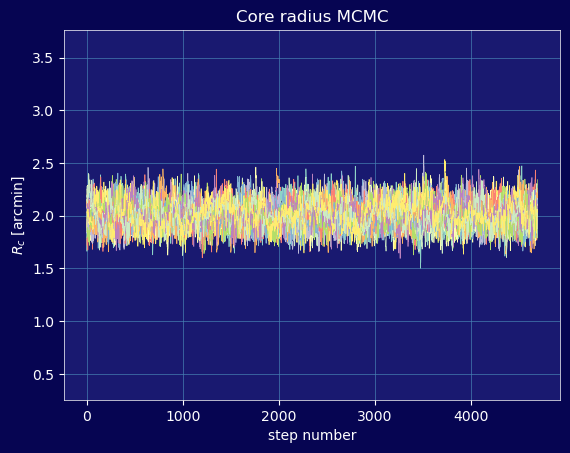

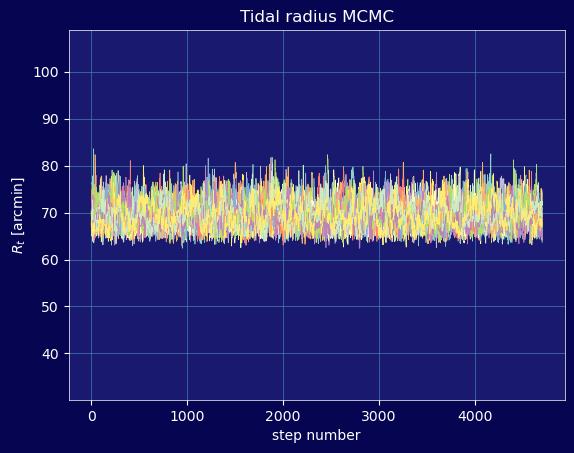

In [66]:
samples_burned = sampler.get_chain(discard = burn_in, flat = False) 
titles = ["Central surface density", "Core radius", "Tidal radius"]
variables = ["$\Sigma_0$", "$R_c$", "$R_t$"]
dimensions = ["stars/arcmin$^2$", "arcmin", "arcmin"]
print('MCMC Chains, Burn-out:')
for i in range(0, 3):
    plt.plot(samples_burned[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{titles[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{variables[i]} [{dimensions[i]}]")
    plt.ylim(np.mean(samples_burned[:,:,i]) - 15*np.std(samples_burned[:,:,i]), 
             np.mean(samples_burned[:,:,i]) + 15*np.std(samples_burned[:,:,i])) # just to see a bit better
    plt.show()

In [67]:
# Computing integrated autocorrelation time for each parameter
n_steps_burnout = n_steps_init - burn_in
taus = []
N_effs = []
taus_bigsample = []
for i in range(3): 
    tau = emcee.autocorr.integrated_time(samples[:,:,i], c = 5, tol = 50, quiet = False)
    N_eff = n_steps_burnout/tau
    tau_bigsample = tau*n_steps_burnout
    # these will then be an array of times in order Sigma_0, R_c, R_t
    taus.append(tau) 
    N_effs.append(N_eff)
    taus_bigsample.append(tau_bigsample)

print(f'Autocorrelation Times:\n---------------------- \nSigma_0: {taus[0]} \nR_c: {taus[1]} \nR_t: {taus[2]}\n')
print(f'Effective Sample Sizes:\n----------------------- \nSigma_0: {N_effs[0]} \nR_c: {N_effs[1]} \nR_t: {N_effs[2]}\n')
print(f'Times to achieve N_eff:\n----------------------- \nSigma_0: {taus_bigsample[0]} \nR_c: {taus_bigsample[1]} \nR_t: {taus_bigsample[2]}')


Autocorrelation Times:
---------------------- 
Sigma_0: [39.31608143] 
R_c: [38.73704595] 
R_t: [36.33460381]

Effective Sample Sizes:
----------------------- 
Sigma_0: [119.54395834] 
R_c: [121.33088327] 
R_t: [129.35327503]

Times to achieve N_eff:
----------------------- 
Sigma_0: [184785.58270096] 
R_c: [182064.11595211] 
R_t: [170772.63791172]


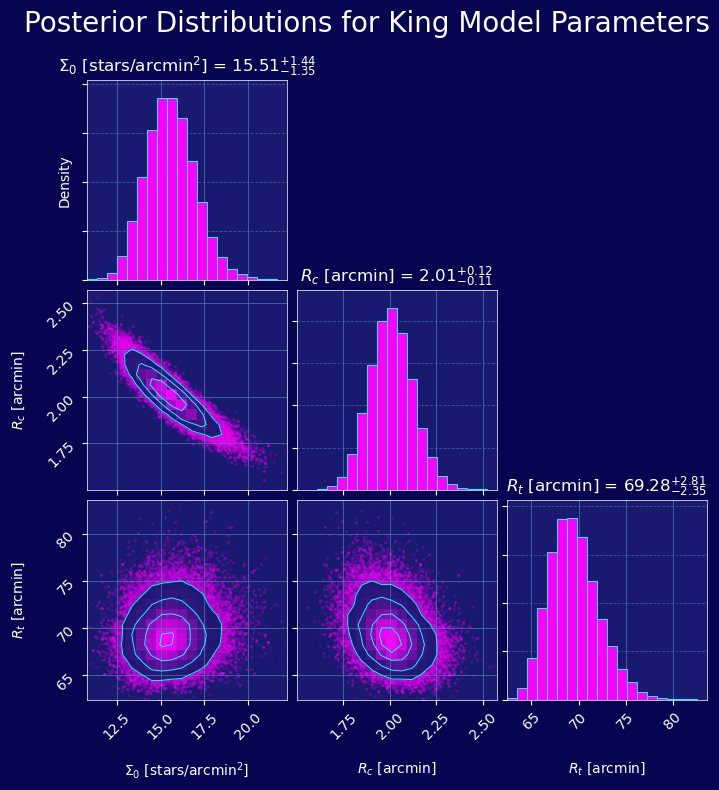

In [68]:
import matplotlib.ticker as mticker
samples_burned_flat = sampler.get_chain(discard = burn_in, flat = True) 
labels = ["$\Sigma_0$ [stars/arcmin$^2$]", 
          "$R_c$ [arcmin]", 
          "$R_t$ [arcmin]"]
fig = corner.corner(samples_burned_flat, labels = labels, show_titles = True, 
                    color="magenta",  # contours + hist edges
                    hist_kwargs={
                        "color": "magenta",
                        "linewidth": 0.7,
                        "histtype": "bar", 
                        "edgecolor": "cyan",
                    },
                    contour_kwargs={
                        "colors": ["cyan"],
                        "linewidths": 0.7
                    },
                    scatter_kwargs={
                        "s": 10,
                        "color": "cyan"
                    }
                )

fig.suptitle('Posterior Distributions for King Model Parameters', fontsize = 20, y = 1.04)

ndim = samples_burned_flat.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0,0].set_ylabel('Density')

# axes[0,0].axvline(78.76, ls = 'dashed', alpha = 0.8, color = 'white', lw = 0.9, label = '$\langle \Sigma_0 \\rangle$')
# axes[1,0].axvline(78.76, ls = 'dashed', alpha = 0.8, color = 'white', lw = 0.9, label = '$\langle \Sigma_0 \\rangle$')
# axes[2,0].axvline(78.76, ls = 'dashed', alpha = 0.8, color = 'white', lw = 0.9, label = '$\langle \Sigma_0 \\rangle$')

# axes[0,0].legend()
# axes[1,0].legend(loc='lower right')
# axes[2,0].legend(loc='lower right')


for i in range(ndim):
    ax = axes[i, i]

    # Force major y-ticks to exist
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))

    # Make sure grid is enabled for y
    ax.grid(True, axis="y", which="major", linestyle="--", alpha=0.6, zorder=0)

    # Draw grid above filled histogram
    ax.set_axisbelow(True)
    

# Force a draw so gridline artists are created
fig.canvas.draw()

plt.show()

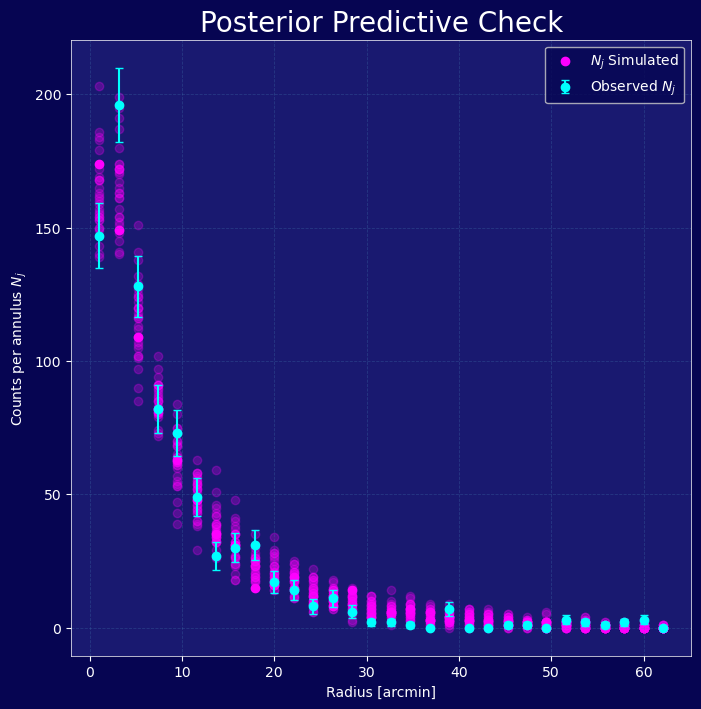

In [69]:
post_pred_check_plot(posterior_sampler=sampler, 
                     burn_in = 300, 
                     R_mid = R_mid_30, 
                     Areas = Areas_30, 
                     Ns = Counts_30, 
                     figsize = (8,8), 
                     n_draws = 30, 
                     seed = 33)

In [343]:
# computing posterior median 
medians = []
credible_intervals = []
for i in range(3): 
    median = np.median(samples_burned[:,:,i])
    credible_int = np.percentile(samples_burned[:,:,i], [16, 50, 84])
    medians.append(median)
    credible_intervals.append(credible_int)

medians = np.array(medians)
credible_intervals = np.array(credible_intervals)

print(f'Sigma_0: \n------ \nMedian: {medians[0]} \nCredible Interval: {credible_intervals[0][0]} - {credible_intervals[0][2]}\n')
print(f'R_c: \n------ \nMedian: {medians[1]} \nCredible Interval: {credible_intervals[1][0]} - {credible_intervals[1][2]}\n')
print(f'R_t: \n------ \nMedian: {medians[2]} \nCredible Interval: {credible_intervals[2][0]} - {credible_intervals[2][2]}')

Sigma_0: 
------ 
Median: 15.514270641576635 
Credible Interval: 14.183651707074521 - 16.92514468794238

R_c: 
------ 
Median: 2.0016683215289017 
Credible Interval: 1.8906994765254854 - 2.118744835926377

R_t: 
------ 
Median: 69.19235976655614 
Credible Interval: 66.87375030340999 - 72.0118135155499
